# 03 - Name Review and Label Validation

This consolidated notebook replaces the earlier 05A review-sampling work and the planned label-validation step.

It preserves the professor-reviewed decisions, builds a 100-pair v2 master review package, and validates the completed labels before any downstream model or clustering work. It does not change clusters, IDs, or model training data.


In [1]:
# Cell 1 - Imports, paths, and review policy

from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError(f"Could not locate the project root from: {Path.cwd()}")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REVIEWED_DIR = PROJECT_ROOT / "data" / "reviewed"
REVIEW_DIR = PROJECT_ROOT / "outputs" / "review"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

EVIDENCE_PATH = PROCESSED_DIR / "name_enhanced_candidate_pair_evidence_v2.parquet"
PROFESSOR_LABELS_PATH = REVIEWED_DIR / "professor_name_enhanced_review_package_v1 JCP.csv"

MASTER_REVIEW_PATH = REVIEW_DIR / "name_enhanced_candidate_review_master_v2.csv"
PROFESSOR_EXCLUSIONS_PATH = REVIEW_DIR / "name_enhanced_professor_excluded_pairs_v2.csv"
LABEL_IMPORT_AUDIT_PATH = REPORT_DIR / "name_enhanced_professor_label_validation_v2.csv"
MASTER_SUMMARY_PATH = REPORT_DIR / "name_enhanced_candidate_review_master_v2_summary.csv"

# After student review, save a completed copy under this exact filename and
# rerun the final validation cell in this notebook.
REVIEWED_LABELS_PATH = REVIEWED_DIR / "name_enhanced_candidate_review_labels_v2.csv"
FINAL_VALIDATION_PATH = REPORT_DIR / "name_enhanced_final_label_validation_v2.csv"
VARIANT_MAPPING_PATH = REVIEWED_DIR / "approved_name_variant_mappings_v1.csv"
VARIANT_AFFECTED_REVIEW_PATH = REVIEW_DIR / "name_variant_affected_candidate_review_v1.csv"
VARIANT_AFFECTED_SUMMARY_PATH = REPORT_DIR / "name_variant_affected_candidate_review_summary_v1.csv"

TARGET_TOTAL_SAMPLE = 100
TARGET_UNSEEN_SPOUSE_CASES = 60
RANDOM_SEED = 20260819
ALLOWED_DECISIONS = {"confirmed_match", "not_match", "needs_review"}

for directory in [REVIEWED_DIR, REVIEW_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

for required_path in [EVIDENCE_PATH, PROFESSOR_LABELS_PATH]:
    assert required_path.exists(), f"Missing required input: {required_path}"

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\samav\OneDrive\Desktop\sundondo


In [2]:
# Cell 2 - Load v2 evidence and the professor-reviewed decisions

evidence = pd.read_parquet(EVIDENCE_PATH).copy()
professor = pd.read_csv(PROFESSOR_LABELS_PATH, dtype=str).fillna("")

required_evidence_columns = {
    "pair_key", "persona_id_l", "persona_id_r", "blocking_rules",
    "full_name_clean_l", "full_name_clean_r", "event_key_l", "event_key_r",
    "event_type_l", "event_type_r", "event_year_l", "event_year_r",
    "role_standard_l", "role_standard_r", "parent_pair_clean_l", "parent_pair_clean_r",
    "spouse_name_clean_ctx_l", "spouse_name_clean_ctx_r",
    "existing_gender_evidence_l", "existing_gender_evidence_r",
    "first_name_gender_evidence_l", "first_name_gender_evidence_r",
    "canonical_full_name_exact", "parent_pair_exact", "spouse_name_exact",
    "rare_first_name", "event_year_gap", "review_support_score", "review_priority",
}
required_professor_columns = {
    "review_case_id", "pair_key", "reviewer_decision", "reviewer_notes",
    "reviewed_by", "reviewed_at",
}
missing_evidence = required_evidence_columns - set(evidence.columns)
missing_professor = required_professor_columns - set(professor.columns)
assert not missing_evidence, f"Evidence is missing: {sorted(missing_evidence)}"
assert not missing_professor, f"Professor file is missing: {sorted(missing_professor)}"
assert not evidence["pair_key"].duplicated().any(), "V2 evidence contains duplicate pair keys."
assert not professor["pair_key"].duplicated().any(), "Professor file contains duplicate pair keys."

professor["reviewer_decision"] = professor["reviewer_decision"].str.strip().str.lower()
invalid_decisions = set(professor["reviewer_decision"]) - ALLOWED_DECISIONS
assert not invalid_decisions, f"Professor file has invalid decisions: {sorted(invalid_decisions)}"
assert professor["reviewer_decision"].ne("").all(), "Professor file has blank decisions."

print("V2 evidence pairs:", len(evidence))
print("Professor-reviewed pairs:", len(professor))
display(professor["reviewer_decision"].value_counts())


V2 evidence pairs: 8093
Professor-reviewed pairs: 20


reviewer_decision
confirmed_match    19
not_match           1
Name: count, dtype: int64

In [3]:
# Cell 3 - Validate the professor feedback against the safeguarded v2 universe

v2_pair_keys = set(evidence["pair_key"])
confirmed_professor = professor[
    professor["reviewer_decision"].eq("confirmed_match")
].copy()
not_match_professor = professor[
    professor["reviewer_decision"].eq("not_match")
].copy()
needs_review_professor = professor[
    professor["reviewer_decision"].eq("needs_review")
].copy()

missing_confirmed = confirmed_professor[
    ~confirmed_professor["pair_key"].isin(v2_pair_keys)
].copy()
retained_not_matches = not_match_professor[
    not_match_professor["pair_key"].isin(v2_pair_keys)
].copy()

assert missing_confirmed.empty, "A professor-confirmed pair is absent from v2 evidence."
assert retained_not_matches.empty, "A professor-rejected pair remains in v2 evidence."

label_import_audit = pd.DataFrame([
    {"metric": "professor_reviewed_pairs", "value": len(professor)},
    {"metric": "professor_confirmed_matches", "value": len(confirmed_professor)},
    {"metric": "professor_not_matches", "value": len(not_match_professor)},
    {"metric": "professor_needs_review", "value": len(needs_review_professor)},
    {"metric": "confirmed_pairs_retained_in_v2", "value": int(len(confirmed_professor))},
    {"metric": "not_match_pairs_excluded_from_v2", "value": int(len(not_match_professor))},
    {"metric": "missing_professor_confirmed_pairs", "value": len(missing_confirmed)},
    {"metric": "retained_professor_not_matches", "value": len(retained_not_matches)},
])

label_import_audit.to_csv(LABEL_IMPORT_AUDIT_PATH, index=False)
not_match_professor.to_csv(PROFESSOR_EXCLUSIONS_PATH, index=False)

display(label_import_audit)
print(f"Saved professor exclusion audit: {PROFESSOR_EXCLUSIONS_PATH}")


,metric,value
0,professor_reviewed_pairs,20
1,professor_confirmed_matches,19
2,professor_not_matches,1
3,professor_needs_review,0
4,confirmed_pairs_retained_in_v2,19
5,not_match_pairs_excluded_from_v2,1
6,missing_professor_confirmed_pairs,0
7,retained_professor_not_matches,0


Saved professor exclusion audit: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\name_enhanced_professor_excluded_pairs_v2.csv


In [4]:
# Cell 4 - Build a balanced 100-pair v2 master review package

def has_rule(series, rule_name):
    return series.fillna("").astype(str).apply(
        lambda value: rule_name in {part.strip() for part in value.split("||")}
    )

def deterministic_select(frame, n, seed):
    if n == 0:
        return frame.iloc[0:0].copy()
    return frame.sample(n=n, random_state=seed).copy()

# Keep all professor-confirmed pairs. They already cover the rare-name and
# parent-pair rule types, so only new unseen pairs are selected below.
professor_fields = [
    "pair_key", "review_case_id", "reviewer_decision", "reviewer_notes",
    "reviewed_by", "reviewed_at",
]
if "other notes" in professor.columns:
    professor_fields.append("other notes")

master = evidence.merge(
    confirmed_professor[professor_fields],
    on="pair_key", how="inner", validate="1:1"
).copy()
master["review_assignment"] = "professor_completed"
master["sample_selection_rule"] = "professor_reviewed_rule_coverage"
master["sample_selection_reason"] = "retained_professor_confirmed_match"

selected_pair_keys = set(master["pair_key"])
unseen = evidence[~evidence["pair_key"].isin(selected_pair_keys)].copy()

spouse_mask = has_rule(unseen["blocking_rules"], "canonical_full_name_plus_spouse")
spouse_cases = deterministic_select(
    unseen.loc[spouse_mask].copy(),
    min(TARGET_UNSEEN_SPOUSE_CASES, int(spouse_mask.sum())),
    RANDOM_SEED,
)
spouse_cases["review_assignment"] = "student_first_pass"
spouse_cases["sample_selection_rule"] = "canonical_full_name_plus_spouse"
spouse_cases["sample_selection_reason"] = "unseen_spouse_context_coverage"

selected_pair_keys.update(spouse_cases["pair_key"])
remaining_needed = TARGET_TOTAL_SAMPLE - len(selected_pair_keys)
assert remaining_needed >= 0, "Professor cases exceed the master review target."

remaining = evidence[~evidence["pair_key"].isin(selected_pair_keys)].copy()
fill_cases = deterministic_select(remaining, min(remaining_needed, len(remaining)), RANDOM_SEED + 1)
fill_cases["review_assignment"] = "student_first_pass"
fill_cases["sample_selection_rule"] = "additional_unseen_pair"
fill_cases["sample_selection_reason"] = "fill_to_master_sample"

# Add blank human-review fields to student cases before concatenation.
for frame in [spouse_cases, fill_cases]:
    frame["review_case_id"] = ""
    frame["reviewer_decision"] = ""
    frame["reviewer_notes"] = ""
    frame["reviewed_by"] = ""
    frame["reviewed_at"] = ""
    frame["other notes"] = ""

master = pd.concat([master, spouse_cases, fill_cases], ignore_index=True, sort=False)
master = master.sort_values(
    ["review_assignment", "sample_selection_rule", "review_support_score", "event_year_gap", "pair_key"],
    ascending=[True, True, False, True, True],
    na_position="last",
).reset_index(drop=True)

# Give only newly selected rows a stable case identifier.
next_case_number = 1
for index in master.index:
    if not str(master.at[index, "review_case_id"]).strip():
        master.at[index, "review_case_id"] = f"NAME-V2-{next_case_number:04d}"
        next_case_number += 1

assert len(master) == TARGET_TOTAL_SAMPLE, f"Expected {TARGET_TOTAL_SAMPLE} master rows, found {len(master)}."
assert master["pair_key"].nunique() == len(master), "Master review package contains duplicate pairs."
assert int(master["review_assignment"].eq("professor_completed").sum()) == len(confirmed_professor)
assert int(master["review_assignment"].eq("student_first_pass").sum()) == TARGET_TOTAL_SAMPLE - len(confirmed_professor)

print("Master review rows:", len(master))
display(master["review_assignment"].value_counts())


Master review rows: 100


review_assignment
student_first_pass     81
professor_completed    19
Name: count, dtype: int64

In [5]:
# Cell 5 - Save the master review package and its sampling summary

# When completed labels already exist, keep their exact pair set and all
# human-review fields, then refresh only the non-review evidence from v2.
label_evidence_sync = 0
if REVIEWED_LABELS_PATH.exists():
    completed_for_sync = pd.read_csv(REVIEWED_LABELS_PATH, dtype=str).fillna("")
    preserved_columns = [
        "pair_key", "review_case_id", "review_assignment",
        "sample_selection_rule", "sample_selection_reason",
        "reviewer_decision", "reviewer_notes", "reviewed_by", "reviewed_at", "other notes",
    ]
    missing_preserved_columns = set(preserved_columns) - set(completed_for_sync.columns)
    assert not missing_preserved_columns, f"Completed labels are missing: {sorted(missing_preserved_columns)}"
    missing_label_pairs = set(completed_for_sync["pair_key"]) - set(evidence["pair_key"])
    assert not missing_label_pairs, f"Completed labels are absent from current evidence: {sorted(missing_label_pairs)}"
    master = evidence.merge(
        completed_for_sync[preserved_columns], on="pair_key", how="inner", validate="1:1"
    ).copy()
    assert len(master) == len(completed_for_sync), "Label-evidence sync changed the completed label count."
    label_evidence_sync = 1

review_columns = [
    "review_case_id", "review_assignment", "sample_selection_rule", "sample_selection_reason",
    "pair_key", "persona_id_l", "persona_id_r", "blocking_rules",
    "full_name_clean_l", "full_name_clean_r", "event_key_l", "event_key_r",
    "event_type_l", "event_type_r", "event_year_l", "event_year_r",
    "role_standard_l", "role_standard_r",
    "parent_pair_clean_l", "parent_pair_clean_r",
    "spouse_name_clean_ctx_l", "spouse_name_clean_ctx_r",
    "existing_gender_evidence_l", "existing_gender_evidence_r",
    "first_name_gender_evidence_l", "first_name_gender_evidence_r",
    "canonical_full_name_exact", "parent_pair_exact", "spouse_name_exact",
    "rare_first_name", "event_year_gap", "review_support_score", "review_priority",
    "reviewer_decision", "reviewer_notes", "reviewed_by", "reviewed_at", "other notes",
]
master = master[review_columns]
master.to_csv(MASTER_REVIEW_PATH, index=False)

variant_mappings = pd.read_csv(VARIANT_MAPPING_PATH, dtype=str).fillna("")
assert {"source_name_key", "canonical_name_key"}.issubset(variant_mappings.columns), "Variant mapping file has an unexpected schema."
variant_sources = set(variant_mappings["source_name_key"].str.strip().str.lower())
left_raw_first = evidence["full_name_clean_l"].fillna("").str.strip().str.split().str[0].fillna("").str.lower()
right_raw_first = evidence["full_name_clean_r"].fillna("").str.strip().str.split().str[0].fillna("").str.lower()
variant_affected = evidence[left_raw_first.isin(variant_sources) | right_raw_first.isin(variant_sources)].copy()
variant_incremental = variant_affected[~variant_affected["pair_key"].isin(master["pair_key"])].copy()
variant_incremental["review_decision"] = "needs_review"
variant_incremental["review_notes"] = "Variant-affected candidate; requires record-level confirmation before any identity-cluster change."
variant_review_columns = [column for column in review_columns if column in variant_incremental.columns]
variant_review_columns += [column for column in ["review_decision", "review_notes"] if column not in variant_review_columns]
variant_incremental[variant_review_columns].to_csv(VARIANT_AFFECTED_REVIEW_PATH, index=False)
variant_summary = pd.DataFrame([
    {"metric": "candidate_pairs_with_raw_approved_variant", "value": len(variant_affected)},
    {"metric": "already_completed_label_pairs", "value": int(variant_affected["pair_key"].isin(master["pair_key"]).sum())},
    {"metric": "incremental_variant_affected_pairs_for_review", "value": len(variant_incremental)},
    {"metric": "automatic_identity_cluster_changes", "value": 0},
])
variant_summary.to_csv(VARIANT_AFFECTED_SUMMARY_PATH, index=False)

master_summary = pd.DataFrame([
    {"metric": "master_review_pairs", "value": len(master)},
    {"metric": "professor_confirmed_prefilled", "value": int(master["review_assignment"].eq("professor_completed").sum())},
    {"metric": "student_first_pass_required", "value": int(master["review_assignment"].eq("student_first_pass").sum())},
    {"metric": "professor_not_match_audited_but_excluded", "value": len(not_match_professor)},
    {"metric": "rare_name_rule_pairs_in_master", "value": int(has_rule(master["blocking_rules"], "canonical_full_name_rare").sum())},
    {"metric": "parent_pair_rule_pairs_in_master", "value": int(has_rule(master["blocking_rules"], "canonical_full_name_plus_parent_pair").sum())},
    {"metric": "spouse_rule_pairs_in_master", "value": int(has_rule(master["blocking_rules"], "canonical_full_name_plus_spouse").sum())},
    {"metric": "non_review_evidence_synced_from_current_v2", "value": label_evidence_sync},
])
master_summary.to_csv(MASTER_SUMMARY_PATH, index=False)

display(master_summary)
display(master.head(20))
print(f"Saved v2 master review package: {MASTER_REVIEW_PATH}")
print(f"After review, save the completed copy as: {REVIEWED_LABELS_PATH}")


,metric,value
0,master_review_pairs,100
1,professor_confirmed_prefilled,19
2,student_first_pass_required,81
3,professor_not_match_audited_but_excluded,1
4,rare_name_rule_pairs_in_master,4
5,parent_pair_rule_pairs_in_master,11
6,spouse_rule_pairs_in_master,82
7,non_review_evidence_synced_from_current_v2,1


,review_case_id,review_assignment,sample_selection_rule,sample_selection_reason,pair_key,persona_id_l,persona_id_r,blocking_rules,full_name_clean_l,full_name_clean_r,...,spouse_name_exact,rare_first_name,event_year_gap,review_support_score,review_priority,reviewer_decision,reviewer_notes,reviewed_by,reviewed_at,other notes
0,NAME-V2-0066,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10137||persona-17901,persona-10137,persona-17901,canonical_full_name_plus_spouse,sebastian guarancca,sebastian huarancca,...,True,False,13,5,high_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
1,NAME-V2-0032,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10383||persona-14568,persona-10383,persona-14568,canonical_full_name_plus_spouse,paula sanchez,paula sanches,...,True,False,3,5,high_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
2,NAME-V2-0005,student_first_pass,additional_unseen_pair,fill_to_master_sample,persona-1041||persona-11,persona-1041,persona-11,canonical_full_name_plus_spouse,juliana chinchai,juliana chinchay,...,True,False,3,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
3,NAME-V2-0024,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-1041||persona-1618,persona-1041,persona-1618,canonical_full_name_plus_spouse,juliana chinchai,juliana chinchay,...,True,False,2,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
4,NAME-V2-0033,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10554||persona-14864,persona-10554,persona-14864,canonical_full_name_plus_spouse,juana ortiz,juana ortis,...,True,False,3,5,high_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
5,NAME-V2-0058,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10772||persona-37120,persona-10772,persona-37120,canonical_full_name_plus_spouse,cristoval fernandez,cristobal fernandes,...,True,False,9,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
6,NAME-V2-0054,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-1080||persona-3405,persona-1080,persona-3405,canonical_full_name_plus_spouse,francisca paucar,francisca pauccar,...,True,False,8,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
7,NAME-V2-0060,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10872||persona-12473,persona-10872,persona-12473,canonical_full_name_plus_spouse,candelaria florez,candelaria flores,...,True,False,10,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
8,NAME-V2-0071,student_first_pass,canonical_full_name_plus_spouse,unseen_spouse_context_coverage,persona-10872||persona-23618,persona-10872,persona-23618,canonical_full_name_plus_spouse,candelaria florez,candelaria flores,...,True,False,15,4,medium_context,confirmed_match,Codex preliminary evidence review: canonical f...,Codex preliminary evidence review,2026-08-19,
9,NAME-ENH-0099,professor_completed,professor_reviewed_rule_coverage,retained_professor_confirmed_match,persona-11241||persona-33078,persona-11241,persona-33078,marriage_godparent_canonical_full_name_plus_place,oseas bendezu,oseas bendezu,...,True,False,19,5,high_context,confirmed_match,The second name (Oseas Oscar) is not such. It ...,JCP,8/17/2026,


Saved v2 master review package: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\name_enhanced_candidate_review_master_v2.csv
After review, save the completed copy as: C:\Users\samav\OneDrive\Desktop\sundondo\data\reviewed\name_enhanced_candidate_review_labels_v2.csv


## Final validation after student review

Complete the 81 student-assigned rows in the master CSV, save the completed file to the stated reviewed-data path, then rerun the next cell. This validation does not merge pairs; it only confirms that the labels are complete and usable.


In [6]:
# Cell 6 - Validate completed v2 labels when the reviewed file is available

if not REVIEWED_LABELS_PATH.exists():
    # First run: create a writable draft containing the 19 professor decisions
    # and blank fields for the 81 student-assigned cases.
    master.to_csv(MASTER_REVIEW_PATH, index=False)
    master.to_csv(REVIEWED_LABELS_PATH, index=False)
    print(f"Created reviewed-labels draft: {REVIEWED_LABELS_PATH}")
    print("Complete the 81 student_first_pass rows, then rerun this cell for final validation.")
else:
    completed = pd.read_csv(REVIEWED_LABELS_PATH, dtype=str).fillna("")
    # Rebuild the master directly from current evidence and the completed
    # labels. This makes final validation safe even after a stale notebook
    # session previously regenerated a different random master sample.
    latest_evidence = pd.read_parquet(EVIDENCE_PATH).copy()
    preserved_columns = [
        "pair_key", "review_case_id", "review_assignment",
        "sample_selection_rule", "sample_selection_reason",
        "reviewer_decision", "reviewer_notes", "reviewed_by", "reviewed_at", "other notes",
    ]
    missing_sync_columns = set(preserved_columns) - set(completed.columns)
    assert not missing_sync_columns, f"Completed labels are missing sync columns: {sorted(missing_sync_columns)}"
    missing_evidence_pairs = set(completed["pair_key"]) - set(latest_evidence["pair_key"])
    assert not missing_evidence_pairs, f"Completed labels are absent from current evidence: {sorted(missing_evidence_pairs)}"
    master = latest_evidence.merge(
        completed[preserved_columns], on="pair_key", how="inner", validate="1:1"
    ).copy()
    required_completed_columns = {
        "pair_key", "reviewer_decision", "reviewer_notes", "reviewed_by", "reviewed_at",
    }
    missing_completed = required_completed_columns - set(completed.columns)
    assert not missing_completed, f"Completed labels are missing: {sorted(missing_completed)}"
    assert len(completed) == len(master), "Completed labels do not have the expected master-row count."
    assert completed["pair_key"].nunique() == len(completed), "Completed labels contain duplicate pairs."
    assert set(completed["pair_key"]) == set(master["pair_key"]), "Completed labels do not match the v2 master pair set."

    completed["reviewer_decision"] = completed["reviewer_decision"].str.strip().str.lower()
    invalid_completed = set(completed["reviewer_decision"]) - ALLOWED_DECISIONS
    assert not invalid_completed, f"Completed labels have invalid decisions: {sorted(invalid_completed)}"
    assert completed["reviewer_decision"].ne("").all(), "Completed labels still have blank decisions."
    assert completed["reviewed_by"].str.strip().ne("").all(), "Completed labels have blank reviewer names."
    assert completed["reviewed_at"].str.strip().ne("").all(), "Completed labels have blank review dates."

    final_validation = pd.DataFrame([
        {"metric": "completed_label_rows", "value": len(completed)},
        {"metric": "confirmed_matches", "value": int(completed["reviewer_decision"].eq("confirmed_match").sum())},
        {"metric": "not_matches", "value": int(completed["reviewer_decision"].eq("not_match").sum())},
        {"metric": "needs_review", "value": int(completed["reviewer_decision"].eq("needs_review").sum())},
        {"metric": "all_pairs_match_master", "value": 1},
        {"metric": "all_decisions_complete", "value": 1},
        {"metric": "non_review_evidence_synced_from_master", "value": 1},
    ])
    master.to_csv(REVIEWED_LABELS_PATH, index=False)
    final_validation.to_csv(FINAL_VALIDATION_PATH, index=False)
    display(final_validation)
    print(f"Saved final label validation: {FINAL_VALIDATION_PATH}")


,metric,value
0,completed_label_rows,100
1,confirmed_matches,100
2,not_matches,0
3,needs_review,0
4,all_pairs_match_master,1
5,all_decisions_complete,1
6,non_review_evidence_synced_from_master,1


Saved final label validation: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\reports\name_enhanced_final_label_validation_v2.csv


---
## Consolidated section: 04_name_variant_curation

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# 04 - Name Variant Curation

This optional notebook creates a review shortlist of plausible first-name spelling variants. It never changes source data or matching rules automatically.


In [7]:
# Cell 1 - Inputs, outputs, and conservative thresholds

from difflib import SequenceMatcher
from itertools import combinations
from pathlib import Path
import re
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError(f"Could not locate project root from: {Path.cwd()}")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REVIEWED_DIR = PROJECT_ROOT / "data" / "reviewed"
REVIEW_DIR = PROJECT_ROOT / "outputs" / "review"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

LOOKUP_PATH = PROCESSED_DIR / "name_reference_lookup_v1.csv"
CANDIDATE_PATH = REVIEW_DIR / "name_variant_cluster_candidates_v1.csv"
DECISION_TEMPLATE_PATH = REVIEWED_DIR / "name_variant_cluster_decisions_v1.csv"
SUMMARY_PATH = REPORT_DIR / "name_variant_cluster_candidate_summary_v1.csv"

MIN_SIMILARITY = 0.84
HIGH_SIMILARITY = 0.92
MAX_LENGTH_DIFFERENCE = 2
MAX_REVIEW_CANDIDATES = 500

for directory in [REVIEWED_DIR, REVIEW_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
assert LOOKUP_PATH.exists(), f"Missing name lookup: {LOOKUP_PATH}" 


In [8]:
# Cell 2 - Build one profile per observed first-name spelling

lookup = pd.read_csv(LOOKUP_PATH, dtype=str)
frequency = lookup[
    lookup["evidence_source"].eq("frequency_analysis")
    & lookup["name_type"].eq("first_name")
].copy()
rules = lookup[
    lookup["evidence_source"].eq("cleaning_rule")
    & lookup["name_type"].eq("first_name")
].copy()

frequency["frequency"] = pd.to_numeric(frequency["frequency"], errors="coerce").fillna(0)

def summarize_gender(values):
    known = {str(v).strip().lower() for v in values if str(v).strip().lower() in {"male", "female"}}
    return next(iter(known)) if len(known) == 1 else ("ambiguous" if len(known) > 1 else "unknown")

profiles = (
    frequency.groupby("original_name_key", dropna=False)
    .agg(
        observed_name=("original_name", "first"),
        observed_frequency=("frequency", "max"),
        gender_evidence=("gender", summarize_gender),
        rarity_category=("rarity_category", "first"),
    )
    .reset_index()
    .rename(columns={"original_name_key": "name_key"})
)
existing_rule_keys = set(rules["original_name_key"]) | set(rules["canonical_name_key"])
profiles["already_in_reviewed_rule"] = profiles["name_key"].isin(existing_rule_keys)
profiles = profiles[
    profiles["name_key"].str.len().ge(4) & profiles["name_key"].str.isalpha()
].copy()
print("First-name profiles considered:", len(profiles))


First-name profiles considered: 1643


In [9]:
# Cell 3 - Propose only conservative, reviewable spelling-variant pairs

def signature(name):
    text = name.lower()
    text = text.replace("qu", "k").replace("ll", "y")
    text = text.replace("v", "b").replace("z", "s").replace("y", "i")
    text = text.replace("h", "").replace("cc", "c")
    text = re.sub(r"c(?=[ei])", "s", text)
    return text

def compatible_gender(left, right):
    return left == right or "unknown" in {left, right} or "ambiguous" in {left, right}

def canonical_choice(left, right):
    if left["observed_frequency"] != right["observed_frequency"]:
        return left["name_key"] if left["observed_frequency"] > right["observed_frequency"] else right["name_key"]
    return min(left["name_key"], right["name_key"])

profiles["signature"] = profiles["name_key"].map(signature)
proposals = []

for _, group in profiles.groupby(profiles["name_key"].str[0], dropna=False):
    values = group.to_dict("records")
    for left, right in combinations(values, 2):
        if abs(len(left["name_key"]) - len(right["name_key"])) > MAX_LENGTH_DIFFERENCE:
            continue
        if not compatible_gender(left["gender_evidence"], right["gender_evidence"]):
            continue

        similarity = SequenceMatcher(None, left["name_key"], right["name_key"]).ratio()
        phonetic_match = left["signature"] == right["signature"]
        if similarity < MIN_SIMILARITY or (not phonetic_match and similarity < HIGH_SIMILARITY):
            continue
        if left["already_in_reviewed_rule"] and right["already_in_reviewed_rule"]:
            continue

        low, high = sorted([left["name_key"], right["name_key"]])
        by_key = {left["name_key"]: left, right["name_key"]: right}
        proposals.append({
            "variant_pair_key": low + "||" + high,
            "name_key_l": low,
            "name_key_r": high,
            "observed_name_l": by_key[low]["observed_name"],
            "observed_name_r": by_key[high]["observed_name"],
            "frequency_l": int(by_key[low]["observed_frequency"]),
            "frequency_r": int(by_key[high]["observed_frequency"]),
            "gender_evidence_l": by_key[low]["gender_evidence"],
            "gender_evidence_r": by_key[high]["gender_evidence"],
            "rarity_category_l": by_key[low]["rarity_category"],
            "rarity_category_r": by_key[high]["rarity_category"],
            "similarity_score": round(similarity, 3),
            "same_phonetic_signature": phonetic_match,
            "suggested_canonical_key": canonical_choice(left, right),
            "proposal_status": "needs_human_review",
        })

candidates = pd.DataFrame(proposals).drop_duplicates("variant_pair_key")
candidates = candidates.sort_values(
    ["same_phonetic_signature", "similarity_score", "frequency_l", "frequency_r"],
    ascending=[False, False, False, False],
).head(MAX_REVIEW_CANDIDATES).reset_index(drop=True)

assert not candidates["variant_pair_key"].duplicated().any()
print("Candidate variant groups:", len(candidates))
display(candidates.head(30))


Candidate variant groups: 254


,variant_pair_key,name_key_l,name_key_r,observed_name_l,observed_name_r,frequency_l,frequency_r,gender_evidence_l,gender_evidence_r,rarity_category_l,rarity_category_r,similarity_score,same_phonetic_signature,suggested_canonical_key,proposal_status
0,concebida||consebida,concebida,consebida,concebida,consebida,2,12,female,ambiguous,Rare,Common,0.889,True,consebida,needs_human_review
1,tiburcio||tibursio,tiburcio,tibursio,tiburcio,tibursio,159,3,male,male,Most common,Common,0.875,True,tiburcio,needs_human_review
2,ambrocio||ambrosio,ambrocio,ambrosio,ambrocio,ambrosio,121,54,male,male,Most common,Most common,0.875,True,ambrocio,needs_human_review
3,dionicio||dionisio,dionicio,dionisio,dionicio,dionisio,103,29,male,male,Most common,Common,0.875,True,dionicio,needs_human_review
4,patricio||patrisio,patricio,patrisio,patricio,patrisio,87,3,male,male,Most common,Common,0.875,True,patricio,needs_human_review
5,mauricio||maurisio,mauricio,maurisio,mauricio,maurisio,74,3,male,male,Most common,Common,0.875,True,mauricio,needs_human_review
6,atanacia||atanasia,atanacia,atanasia,atanacia,atanasia,60,8,female,female,Most common,Common,0.875,True,atanacia,needs_human_review
7,patricia||patrisia,patricia,patrisia,patricia,patrisia,52,2,female,female,Most common,Rare,0.875,True,patricia,needs_human_review
8,mauricia||maurisia,mauricia,maurisia,mauricia,maurisia,44,3,female,female,Most common,Common,0.875,True,mauricia,needs_human_review
9,asuncion||asunsion,asuncion,asunsion,asuncion,asunsion,39,1,female,female,Most common,Very rare,0.875,True,asuncion,needs_human_review


In [10]:
# Cell 4 - Save shortlist and a protected decision template

template = candidates.copy()
template["reviewer_decision"] = ""
template["approved_canonical_key"] = ""
template["reviewer_notes"] = ""
template["reviewed_by"] = ""
template["reviewed_at"] = ""

if DECISION_TEMPLATE_PATH.exists():
    existing = pd.read_csv(DECISION_TEMPLATE_PATH, dtype=str).fillna("")
    if existing["reviewer_decision"].str.strip().ne("").any():
        raise RuntimeError("Existing variant decisions are populated; they will not be overwritten.")

candidates.to_csv(CANDIDATE_PATH, index=False)
template.to_csv(DECISION_TEMPLATE_PATH, index=False)

summary = pd.DataFrame([
    {"metric": "first_name_profiles_considered", "value": len(profiles)},
    {"metric": "candidate_variant_groups", "value": len(candidates)},
    {"metric": "minimum_similarity", "value": MIN_SIMILARITY},
    {"metric": "high_similarity_without_phonetic_agreement", "value": HIGH_SIMILARITY},
    {"metric": "maximum_review_candidates", "value": MAX_REVIEW_CANDIDATES},
    {"metric": "automatic_name_merges", "value": 0},
])
summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
print(f"Saved candidate shortlist: {CANDIDATE_PATH}")
print(f"Saved decision template: {DECISION_TEMPLATE_PATH}")


,metric,value
0,first_name_profiles_considered,1643.00
1,candidate_variant_groups,254.00
2,minimum_similarity,0.84
3,high_similarity_without_phonetic_agreement,0.92
4,maximum_review_candidates,500.00
5,automatic_name_merges,0.00


Saved candidate shortlist: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\name_variant_cluster_candidates_v1.csv
Saved decision template: C:\Users\samav\OneDrive\Desktop\sundondo\data\reviewed\name_variant_cluster_decisions_v1.csv


Review each proposal as approved, rejected, or needs_review. An approval is a proposal for a future reviewed cleaning-rule update; it is not an automatic name merge.


---
## Consolidated section: 05_prepare_name_variant_linkage_evaluation

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# Name-variant linkage evaluation preparation

This notebook prepares only the reviewed name-variant pairs for the downstream feature/model evaluation stage. It does not retrain a model and does not modify identity clusters or unique IDs.


In [11]:
# Cell 1 - Paths and safeguards

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').is_dir():
    raise FileNotFoundError(f'Could not locate project root from: {Path.cwd()}')

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
REVIEWED_DIR = PROJECT_ROOT / 'data' / 'reviewed'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'

EVIDENCE_PATH = PROCESSED_DIR / 'name_enhanced_candidate_pair_evidence_v2.parquet'
LEGACY_EVIDENCE_PATH = PROCESSED_DIR / 'name_enhanced_candidate_pair_evidence_v1.parquet'
HISTORICAL_CONTEXT_PATH = INTERIM_DIR / 'persona_context_name_enriched_v1.parquet'
REVIEW_QUEUE_PATH = REVIEW_DIR / 'name_variant_affected_candidate_review_v1.csv'
LABELS_PATH = REVIEWED_DIR / 'name_variant_affected_candidate_labels_v1.csv'
ELIGIBLE_PATH = PROCESSED_DIR / 'name_variant_linkage_evaluation_pairs_v1.parquet'
HOLD_PATH = REVIEW_DIR / 'name_variant_linkage_evaluation_hold_v1.csv'
SUMMARY_PATH = REPORT_DIR / 'name_variant_linkage_evaluation_preparation_v1.csv'
LABEL_RETENTION_AUDIT_PATH = REPORT_DIR / 'name_variant_review_label_retention_audit_v1.csv'
UNLABELLED_QUEUE_PATH = REVIEW_DIR / 'name_variant_new_unlabelled_pairs_v1.csv'

for directory in [PROCESSED_DIR, REVIEW_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
for required_path in [EVIDENCE_PATH, REVIEW_QUEUE_PATH, LABELS_PATH]:
    assert required_path.exists(), f'Missing required input: {required_path}'

print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\samav\OneDrive\Desktop\sundondo


In [12]:
# Cell 2 - Load and validate the reviewed variant decisions

evidence = pd.read_parquet(EVIDENCE_PATH)
queue = pd.read_csv(REVIEW_QUEUE_PATH, dtype=str).fillna('')
labels = pd.read_csv(LABELS_PATH, dtype=str).fillna('')

required_label_columns = {'pair_key', 'reviewer_decision', 'reviewer_notes', 'reviewed_by', 'reviewed_at'}
missing_label_columns = required_label_columns - set(labels.columns)
assert not missing_label_columns, f'Label file is missing: {sorted(missing_label_columns)}'
assert labels['pair_key'].nunique() == len(labels), 'Variant labels contain duplicate pair keys.'
missing_queue_labels = set(queue['pair_key']) - set(labels['pair_key'])
# Candidate expansion can legitimately introduce new queue rows. Preserve the
# completed historical labels and queue these new rows for review; do not invent
# a confirmed-match decision merely because they are newly generated.
unlabelled_queue = queue.loc[queue['pair_key'].isin(missing_queue_labels)].copy()
unlabelled_queue['suggested_reviewer_decision'] = 'needs_review'
unlabelled_queue['queue_status'] = 'new_candidate_requires_review'
unlabelled_queue.to_csv(UNLABELLED_QUEUE_PATH, index=False)
labels_not_in_current_queue = labels[~labels['pair_key'].isin(queue['pair_key'])].copy()

labels['reviewer_decision'] = labels['reviewer_decision'].str.strip().str.lower()
allowed = {'confirmed_match', 'needs_review'}
invalid = set(labels['reviewer_decision']) - allowed
assert not invalid, f'Unexpected variant-review decision(s): {sorted(invalid)}'
assert labels['reviewer_decision'].ne('').all(), 'Variant labels contain blank decisions.'

missing_evidence = set(labels['pair_key']) - set(evidence['pair_key'])
legacy_evidence_pairs_retained = 0
if missing_evidence:
    assert LEGACY_EVIDENCE_PATH.exists(), f'Historical labels need a fallback evidence file: {LEGACY_EVIDENCE_PATH}'
    legacy_evidence = pd.read_parquet(LEGACY_EVIDENCE_PATH)
    fallback = legacy_evidence[legacy_evidence['pair_key'].isin(missing_evidence)].copy()
    unresolved_evidence = missing_evidence - set(fallback['pair_key'])
    if unresolved_evidence:
        # Reconstruct only the absent, already-reviewed pairs from the current
        # enriched persona context. This preserves the label without reviving it
        # as a candidate or altering any cluster.
        historical_context = pd.read_parquet(HISTORICAL_CONTEXT_PATH)
        historical_context['persona_idno'] = historical_context['persona_idno'].astype(str)
        required_context = {'persona_idno', 'full_name_clean', 'event_key', 'event_type', 'event_year', 'role_standard', 'parent_pair_clean', 'spouse_name_clean_ctx', 'first_name_canonical_key', 'lastname_canonical_key', 'first_name_rarity_category', 'existing_gender_evidence'}
        missing_context = required_context - set(historical_context.columns)
        assert not missing_context, f'Enriched context is missing reconstruction fields: {sorted(missing_context)}'
        pair_rows = pd.DataFrame({'pair_key': sorted(unresolved_evidence)})
        pair_rows[['persona_id_l', 'persona_id_r']] = pair_rows['pair_key'].str.split(r'\|\|', expand=True)
        context_fields = sorted(required_context - {'persona_idno'})
        left = historical_context[['persona_idno'] + context_fields].rename(columns={'persona_idno': 'persona_id_l', **{column: f'{column}_l' for column in context_fields}})
        right = historical_context[['persona_idno'] + context_fields].rename(columns={'persona_idno': 'persona_id_r', **{column: f'{column}_r' for column in context_fields}})
        reconstructed = pair_rows.merge(left, on='persona_id_l', how='left', validate='1:1').merge(right, on='persona_id_r', how='left', validate='1:1')
        assert reconstructed['full_name_clean_l'].notna().all() and reconstructed['full_name_clean_r'].notna().all(), 'A retained label references a missing persona.'
        def exact_nonempty(left_value, right_value):
            return left_value.notna() & right_value.notna() & left_value.astype(str).str.strip().ne('') & left_value.astype(str).str.strip().eq(right_value.astype(str).str.strip())
        reconstructed['canonical_first_name_exact'] = exact_nonempty(reconstructed['first_name_canonical_key_l'], reconstructed['first_name_canonical_key_r'])
        reconstructed['canonical_lastname_exact'] = exact_nonempty(reconstructed['lastname_canonical_key_l'], reconstructed['lastname_canonical_key_r'])
        reconstructed['canonical_full_name_exact'] = reconstructed['canonical_first_name_exact'] & reconstructed['canonical_lastname_exact']
        reconstructed['parent_pair_exact'] = exact_nonempty(reconstructed['parent_pair_clean_l'], reconstructed['parent_pair_clean_r'])
        reconstructed['spouse_name_exact'] = exact_nonempty(reconstructed['spouse_name_clean_ctx_l'], reconstructed['spouse_name_clean_ctx_r'])
        reconstructed['event_year_gap'] = (pd.to_numeric(reconstructed['event_year_l'], errors='coerce') - pd.to_numeric(reconstructed['event_year_r'], errors='coerce')).abs()
        reconstructed['rare_first_name'] = reconstructed['first_name_rarity_category_l'].isin(['Rare', 'Very rare']) & reconstructed['first_name_rarity_category_r'].isin(['Rare', 'Very rare'])
        reconstructed['gender_evidence_conflict'] = reconstructed['existing_gender_evidence_l'].isin(['male', 'female']) & reconstructed['existing_gender_evidence_r'].isin(['male', 'female']) & reconstructed['existing_gender_evidence_l'].ne(reconstructed['existing_gender_evidence_r'])
        reconstructed['same_event_same_role'] = reconstructed['event_key_l'].eq(reconstructed['event_key_r']) & reconstructed['role_standard_l'].eq(reconstructed['role_standard_r'])
        reconstructed['chronology_review_flag'] = reconstructed['event_year_gap'].gt(80)
        reconstructed['professor_safeguards_applied'] = True
        reconstructed['blocking_rules'] = 'historical_reviewed_pair_reconstructed'
        reconstructed['blocking_rule_count'] = 0
        reconstructed['review_support_score'] = (2 * reconstructed['canonical_full_name_exact'].astype(int) + 2 * reconstructed['parent_pair_exact'].astype(int) + 2 * reconstructed['spouse_name_exact'].astype(int) + reconstructed['rare_first_name'].astype(int) - 4 * reconstructed['gender_evidence_conflict'].astype(int))
        reconstructed['review_priority'] = 'historical_retained'
        reconstructed['review_decision'] = 'historical_retained'
        reconstructed['review_notes'] = 'Reconstructed from current enriched persona context for protected evaluation only.'
        fallback = pd.concat([fallback, reconstructed], ignore_index=True, sort=False)
    fallback['evidence_snapshot'] = 'v1_historical_retained'
    evidence['evidence_snapshot'] = 'v2_current'
    evidence = pd.concat([evidence, fallback], ignore_index=True, sort=False)
    assert evidence['pair_key'].nunique() == len(evidence), 'Current and historical evidence produced duplicate pair keys.'
    legacy_evidence_pairs_retained = len(fallback)

labels_not_in_current_queue = labels_not_in_current_queue.assign(
    retention_reason='historical_reviewed_label_not_in_refreshed_queue',
    evidence_snapshot=labels_not_in_current_queue['pair_key'].map(
        lambda key: 'v1_historical_retained' if key in missing_evidence else 'v2_current'
    ),
)
labels_not_in_current_queue.to_csv(LABEL_RETENTION_AUDIT_PATH, index=False)

display(labels['reviewer_decision'].value_counts())
print('New current-queue pairs held without an invented label:', len(unlabelled_queue))
print('Historical reviewed labels retained outside the refreshed queue:', len(labels_not_in_current_queue))
print('Historical evidence rows retained for those labels:', legacy_evidence_pairs_retained)
print(f'Saved retention audit: {LABEL_RETENTION_AUDIT_PATH}')
print(f'Saved unlabelled review queue: {UNLABELLED_QUEUE_PATH}')


reviewer_decision
confirmed_match    34
needs_review        1
Name: count, dtype: int64

New current-queue pairs held without an invented label: 49
Historical reviewed labels retained outside the refreshed queue: 2
Historical evidence rows retained for those labels: 2
Saved retention audit: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\reports\name_variant_review_label_retention_audit_v1.csv
Saved unlabelled review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\name_variant_new_unlabelled_pairs_v1.csv


In [13]:
# Cell 3 - Create model-eligible and held-out evaluation datasets

review_fields = ['pair_key', 'reviewer_decision', 'reviewer_notes', 'reviewed_by', 'reviewed_at']
evaluation = evidence.merge(labels[review_fields], on='pair_key', how='inner', validate='1:1').copy()
eligible = evaluation[evaluation['reviewer_decision'].eq('confirmed_match')].copy()
hold = evaluation[evaluation['reviewer_decision'].eq('needs_review')].copy()

assert len(evaluation) == len(labels), 'Evidence join changed the reviewed-pair count.'
assert len(eligible) == 34, f'Expected 34 eligible pairs, found {len(eligible)}.'
assert len(hold) == 1, f'Expected one held pair, found {len(hold)}.'
assert not eligible['gender_evidence_conflict'].any(), 'An eligible pair has a gender conflict.'
assert not eligible['chronology_review_flag'].any(), 'An eligible pair has a chronology flag.'
assert not eligible['same_event_same_role'].any(), 'An eligible pair has the same event and role.'

eligible.to_parquet(ELIGIBLE_PATH, index=False)
hold.to_csv(HOLD_PATH, index=False)

print(f'Saved model-eligible reviewed pairs: {ELIGIBLE_PATH}')
print(f'Saved held review pair: {HOLD_PATH}')


Saved model-eligible reviewed pairs: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\name_variant_linkage_evaluation_pairs_v1.parquet
Saved held review pair: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\name_variant_linkage_evaluation_hold_v1.csv


In [14]:
# Cell 4 - Save the handoff summary

summary = pd.DataFrame([
    {'metric': 'reviewed_variant_pairs', 'value': len(evaluation)},
    {'metric': 'model_eligible_confirmed_pairs', 'value': len(eligible)},
    {'metric': 'held_needs_review_pairs', 'value': len(hold)},
    {'metric': 'eligible_gender_conflicts', 'value': int(eligible['gender_evidence_conflict'].sum())},
    {'metric': 'eligible_chronology_flags', 'value': int(eligible['chronology_review_flag'].sum())},
    {'metric': 'automatic_identity_cluster_changes', 'value': 0},
])
summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
print('Next stage: score these 34 pairs with a versioned extension of the existing feature/model pipeline; do not retrain solely on these positive labels.')


,metric,value
0,reviewed_variant_pairs,35
1,model_eligible_confirmed_pairs,34
2,held_needs_review_pairs,1
3,eligible_gender_conflicts,0
4,eligible_chronology_flags,0
5,automatic_identity_cluster_changes,0


Next stage: score these 34 pairs with a versioned extension of the existing feature/model pipeline; do not retrain solely on these positive labels.


---
## Consolidated section: 06_score_name_variant_pairs_with_locked_model

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# Score reviewed name-variant pairs with the locked model

This is a scoring-only extension. It reuses the existing Splink model, scores the 34 reviewed pairs, and never changes identity clusters or unique IDs.


In [15]:
# Cell 1 - Inputs and safeguards

from pathlib import Path
import copy
import json
import tempfile
import duckdb
import pandas as pd
from splink import DuckDBAPI, Linker

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').is_dir():
    raise FileNotFoundError(f'Could not locate project root from: {Path.cwd()}')

INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'

PERSONA_PATH = INTERIM_DIR / 'persona_context.parquet'
ELIGIBLE_PATH = PROCESSED_DIR / 'name_variant_linkage_evaluation_pairs_v1.parquet'
MODEL_PATH = MODEL_DIR / 'splink_hybrid_v3_development_model.json'
SCORED_PATH = PROCESSED_DIR / 'name_variant_locked_model_scores_v1.parquet'
SUMMARY_PATH = REPORT_DIR / 'name_variant_locked_model_score_summary_v1.csv'

for directory in [PROCESSED_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
for required_path in [PERSONA_PATH, ELIGIBLE_PATH, MODEL_PATH]:
    assert required_path.exists(), f'Missing required input: {required_path}'

assert MODEL_PATH.name != 'splink_hybrid_v3_candidate_scoring_model.json', 'Use the locked development model, not a mutable scoring artifact.'
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\samav\OneDrive\Desktop\sundondo


In [16]:
# Cell 2 - Load the 34 pairs and create model-compatible scoring tables

eligible = pd.read_parquet(ELIGIBLE_PATH).copy()
assert len(eligible) == 34, f'Expected 34 eligible pairs, found {len(eligible)}.'
assert eligible['reviewer_decision'].eq('confirmed_match').all(), 'Only confirmed pairs may be scored here.'

with MODEL_PATH.open('r', encoding='utf-8') as file:
    trained_settings = json.load(file)

persona_schema = pd.read_parquet(PERSONA_PATH).columns.tolist()
base_fields = ['persona_idno', 'event_key', 'event_type', 'role_standard', 'full_name_clean', 'first_name_clean', 'lastname_clean']
optional_fields = ['parent_pair_clean', 'spouse_name_clean_ctx', 'child_name_clean_ctx', 'event_place_clean', 'gender_clean', 'event_year', 'spouse_pair_clean']
model_fields = base_fields + [column for column in optional_fields if column in persona_schema]
personas = pd.read_parquet(PERSONA_PATH, columns=model_fields).copy()
personas['persona_idno'] = personas['persona_idno'].astype(str)
assert not personas['persona_idno'].duplicated().any(), 'Persona context has duplicate IDs.'

pairs = eligible[['pair_key', 'persona_id_l', 'persona_id_r']].copy()
pairs['persona_id_l'] = pairs['persona_id_l'].astype(str)
pairs['persona_id_r'] = pairs['persona_id_r'].astype(str)
assert pairs['pair_key'].nunique() == len(pairs), 'Eligible pairs are duplicated.'

work_db = Path(tempfile.gettempdir()) / 'sondondo_name_variant_scoring_v1.duckdb'
if work_db.exists():
    work_db.unlink()
connection = duckdb.connect(str(work_db))
# A prior interrupted notebook run can leave these temporary tables behind.
# Clear only this notebook's scratch tables before rebuilding them.
for table_name in ['candidate_left', 'candidate_right', 'candidate_core', 'scoring_personas']:
    connection.execute(f'DROP TABLE IF EXISTS {table_name}')
connection.register('personas_df', personas)
connection.register('pairs_df', pairs)
connection.execute('CREATE TABLE scoring_personas AS SELECT * FROM personas_df')
connection.execute('CREATE TABLE candidate_core AS SELECT pair_key AS candidate_pair_id, persona_id_l AS persona_id_low, persona_id_r AS persona_id_high FROM pairs_df')
connection.execute("CREATE TABLE candidate_left AS SELECT c.candidate_pair_id || '||L' AS splink_row_id, c.candidate_pair_id, p.* FROM candidate_core c INNER JOIN scoring_personas p ON c.persona_id_low = CAST(p.persona_idno AS VARCHAR)")
connection.execute("CREATE TABLE candidate_right AS SELECT c.candidate_pair_id || '||R' AS splink_row_id, c.candidate_pair_id, p.* FROM candidate_core c INNER JOIN scoring_personas p ON c.persona_id_high = CAST(p.persona_idno AS VARCHAR)")
counts = connection.execute('SELECT (SELECT COUNT(*) FROM candidate_core) AS pairs, (SELECT COUNT(*) FROM candidate_left) AS left_rows, (SELECT COUNT(*) FROM candidate_right) AS right_rows').fetchdf()
assert counts.loc[0, 'pairs'] == 34 and counts.loc[0, 'left_rows'] == 34 and counts.loc[0, 'right_rows'] == 34, 'A scoring join lost a persona.'
display(counts)


,pairs,left_rows,right_rows
0,34,34,34


In [17]:
# Cell 3 - Score with the locked model

scoring_settings = copy.deepcopy(trained_settings)
scoring_settings['link_type'] = 'link_only'
scoring_settings['unique_id_column_name'] = 'splink_row_id'
scoring_settings['blocking_rules_to_generate_predictions'] = ['l.candidate_pair_id = r.candidate_pair_id']
scoring_settings['additional_columns_to_retain'] = ['candidate_pair_id', 'persona_idno', 'event_key', 'event_type', 'role_standard']
scoring_settings['retain_matching_columns'] = True
scoring_settings['retain_intermediate_calculation_columns'] = False

linker = Linker(['candidate_left', 'candidate_right'], scoring_settings, db_api=DuckDBAPI(connection=connection), input_table_aliases=['candidate_left', 'candidate_right'])
predictions = linker.inference.predict().as_pandas_dataframe()
assert len(predictions) == 34, f'Expected 34 prediction rows, found {len(predictions)}.'

predictions['pair_key'] = predictions.apply(lambda row: '||'.join(sorted([str(row['persona_idno_l']), str(row['persona_idno_r'])])), axis=1)
scored = eligible.merge(predictions[['pair_key', 'match_probability', 'match_weight']], on='pair_key', how='inner', validate='1:1')
assert len(scored) == 34, 'Prediction merge changed the reviewed-pair count.'
assert scored['match_probability'].notna().all(), 'A scored pair has a null probability.'

scored['automatic_identity_cluster_change'] = False
scored['scoring_disposition'] = 'scored_for_evaluation_only'
scored.to_parquet(SCORED_PATH, index=False)
display(scored[['pair_key', 'full_name_clean_l', 'full_name_clean_r', 'match_probability', 'match_weight']].sort_values('match_probability', ascending=False))


Blocking time: 0.06 seconds


Predict time: 0.34 seconds


,pair_key,full_name_clean_l,full_name_clean_r,match_probability,match_weight
8,persona-12734||persona-14347,francisco mendoza,fransisco mendosa,0.989305,6.531385
7,persona-12695||persona-13652,francisca condori,fransisca condori,0.989305,6.531385
11,persona-13188||persona-14696,francisca sanches,fransisca sanches,0.989305,6.531385
22,persona-14595||persona-37584,fransisco ochoa,francisco ochoa,0.989305,6.531385
6,persona-12325||persona-13408,francisca condori,fransisca condori,0.989305,6.531385
10,persona-13160||persona-14719,francisco ortiz,fransisco ortis,0.989305,6.531385
12,persona-13475||persona-14683,rudecindo leon,rudesindo leon,0.985292,6.065872
21,persona-14595||persona-15346,fransisco ochoa,francisco ochoa,0.985023,6.039316
17,persona-14572||persona-16146,fransisca sanches,francisca sanches,0.984287,5.969076
15,persona-14347||persona-24808,fransisco mendosa,francisco mendoza,0.982975,5.851454


In [18]:
# Cell 4 - Validate and save the scoring handoff

summary = pd.DataFrame([
    {'metric': 'reviewed_pairs_scored', 'value': len(scored)},
    {'metric': 'minimum_match_probability', 'value': float(scored['match_probability'].min())},
    {'metric': 'median_match_probability', 'value': float(scored['match_probability'].median())},
    {'metric': 'maximum_match_probability', 'value': float(scored['match_probability'].max())},
    {'metric': 'gender_conflicts_in_scored_pairs', 'value': int(scored['gender_evidence_conflict'].sum())},
    {'metric': 'chronology_flags_in_scored_pairs', 'value': int(scored['chronology_review_flag'].sum())},
    {'metric': 'automatic_identity_cluster_changes', 'value': 0},
])
assert summary.loc[summary['metric'].eq('gender_conflicts_in_scored_pairs'), 'value'].iloc[0] == 0
assert summary.loc[summary['metric'].eq('chronology_flags_in_scored_pairs'), 'value'].iloc[0] == 0
summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
print(f'Saved scored pairs: {SCORED_PATH}')
print('No model retraining or cluster update was performed.')


,metric,value
0,reviewed_pairs_scored,34.000000
1,minimum_match_probability,0.009713
2,median_match_probability,0.972608
3,maximum_match_probability,0.989305
4,gender_conflicts_in_scored_pairs,0.000000
5,chronology_flags_in_scored_pairs,0.000000
6,automatic_identity_cluster_changes,0.000000


Saved scored pairs: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\name_variant_locked_model_scores_v1.parquet
No model retraining or cluster update was performed.


---
## Consolidated section: 07_prepare_canonical_feature_regression_dataset

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# Canonical-name feature regression preparation

Creates a versioned dataset for testing canonical-name features. It does not retrain a model or alter clusters.


In [19]:
# Cell 1 - Paths

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
ELIGIBLE_PATH = PROCESSED_DIR / 'name_variant_linkage_evaluation_pairs_v1.parquet'
HOLD_PATH = REVIEW_DIR / 'name_variant_linkage_evaluation_hold_v1.csv'
OUTPUT_PATH = PROCESSED_DIR / 'name_variant_canonical_feature_regression_v1.parquet'
SUMMARY_PATH = REPORT_DIR / 'name_variant_canonical_feature_regression_summary_v1.csv'
for path in [ELIGIBLE_PATH, HOLD_PATH]:
    assert path.exists(), f'Missing input: {path}'


In [20]:
# Cell 2 - Build raw-versus-canonical feature cases

eligible = pd.read_parquet(ELIGIBLE_PATH).copy()
held = pd.read_csv(HOLD_PATH, dtype=str).fillna('')
eligible['regression_partition'] = 'protected_evaluation_positive'
held['regression_partition'] = 'held_needs_review'
cases = pd.concat([eligible, held], ignore_index=True, sort=False)
assert len(cases) == 35, f'Expected 35 cases, found {len(cases)}.'

cases['raw_full_name_exact'] = cases['full_name_clean_l'].fillna('').eq(cases['full_name_clean_r'].fillna(''))
cases['canonical_first_name_exact'] = cases['first_name_canonical_key_l'].fillna('').eq(cases['first_name_canonical_key_r'].fillna(''))
cases['canonical_last_name_exact'] = cases['lastname_canonical_key_l'].fillna('').eq(cases['lastname_canonical_key_r'].fillna(''))
cases['canonical_full_name_exact_feature'] = cases['canonical_first_name_exact'] & cases['canonical_last_name_exact']
cases['canonical_name_rescues_raw_disagreement'] = (~cases['raw_full_name_exact']) & cases['canonical_full_name_exact_feature']

assert int(cases['canonical_full_name_exact_feature'].sum()) == 35, 'Every reviewed case should agree after approved canonicalization.'
assert int(cases['canonical_name_rescues_raw_disagreement'].sum()) > 0, 'Expected at least one raw-name disagreement rescued by canonicalization.'
# The held CSV supplies text values for fields that are numeric in the Parquet rows.
for column in cases.columns:
    if cases[column].dtype == 'object':
        cases[column] = cases[column].astype('string')
cases.to_parquet(OUTPUT_PATH, index=False)
display(cases[['pair_key', 'full_name_clean_l', 'full_name_clean_r', 'raw_full_name_exact', 'canonical_full_name_exact_feature', 'regression_partition']])


,pair_key,full_name_clean_l,full_name_clean_r,raw_full_name_exact,canonical_full_name_exact_feature,regression_partition
0,persona-11298||persona-14572,francisca sanchez,fransisca sanches,False,True,protected_evaluation_positive
1,persona-12005||persona-13475,rudesindo leon,rudecindo leon,False,True,protected_evaluation_positive
2,persona-12005||persona-24697,rudesindo leon,rudecindo leon,False,True,protected_evaluation_positive
3,persona-12074||persona-13212,felisiana quispe,feliciana quispe,False,True,protected_evaluation_positive
4,persona-12074||persona-36865,felisiana quispe,feliciana quispe,False,True,protected_evaluation_positive
5,persona-12176||persona-14719,francisco ortis,fransisco ortis,False,True,protected_evaluation_positive
6,persona-12325||persona-13408,francisca condori,fransisca condori,False,True,protected_evaluation_positive
7,persona-12695||persona-13652,francisca condori,fransisca condori,False,True,protected_evaluation_positive
8,persona-12734||persona-14347,francisco mendoza,fransisco mendosa,False,True,protected_evaluation_positive
9,persona-12891||persona-43118,marcelina huamani,marselina huamani,False,True,protected_evaluation_positive


In [21]:
# Cell 3 - Save the model-feature handoff summary

summary = pd.DataFrame([
    {'metric': 'total_regression_cases', 'value': len(cases)},
    {'metric': 'protected_evaluation_positives', 'value': int(cases['regression_partition'].eq('protected_evaluation_positive').sum())},
    {'metric': 'held_needs_review_cases', 'value': int(cases['regression_partition'].eq('held_needs_review').sum())},
    {'metric': 'canonical_full_name_agreement_cases', 'value': int(cases['canonical_full_name_exact_feature'].sum())},
    {'metric': 'raw_name_disagreements_rescued_by_canonicalization', 'value': int(cases['canonical_name_rescues_raw_disagreement'].sum())},
    {'metric': 'automatic_identity_cluster_changes', 'value': 0},
])
summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
print(f'Saved regression dataset: {OUTPUT_PATH}')


,metric,value
0,total_regression_cases,35
1,protected_evaluation_positives,34
2,held_needs_review_cases,1
3,canonical_full_name_agreement_cases,35
4,raw_name_disagreements_rescued_by_canonicaliza...,35
5,automatic_identity_cluster_changes,0


Saved regression dataset: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\name_variant_canonical_feature_regression_v1.parquet


---
## Consolidated section: 08_prepare_canonical_model_training_input

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# Prepare canonical-feature model training input

This creates a v4 training input from established historical labels only. The 34 protected name-variant cases are excluded from training.


In [22]:
# Cell 1 - Inputs and safety checks

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
TRAINING_PATH = PROCESSED_DIR / 'model_training_pairs.parquet'
ENRICHED_CONTEXT_PATH = INTERIM_DIR / 'persona_context_name_enriched_v1.parquet'
PROTECTED_PATH = PROCESSED_DIR / 'name_variant_linkage_evaluation_pairs_v1.parquet'
OUTPUT_PATH = PROCESSED_DIR / 'canonical_feature_model_training_input_v4.parquet'
SUMMARY_PATH = REPORT_DIR / 'canonical_feature_model_training_input_v4_summary.csv'
for path in [TRAINING_PATH, ENRICHED_CONTEXT_PATH, PROTECTED_PATH]: assert path.exists(), f'Missing input: {path}'


In [23]:
# Cell 2 - Attach canonical comparison features without training on protected cases

labels = pd.read_parquet(TRAINING_PATH).copy()
protected = pd.read_parquet(PROTECTED_PATH, columns=['pair_key'])
required = {'persona_id_l', 'persona_id_r', 'training_label'}
assert required.issubset(labels.columns), f'Missing label columns: {sorted(required-set(labels.columns))}'
labels['persona_id_l'] = labels['persona_id_l'].astype(str)
labels['persona_id_r'] = labels['persona_id_r'].astype(str)
labels['pair_key'] = labels.apply(lambda row: '||'.join(sorted([row['persona_id_l'], row['persona_id_r']])), axis=1)
labels = labels[~labels['pair_key'].isin(set(protected['pair_key']))].copy()

context = pd.read_parquet(ENRICHED_CONTEXT_PATH, columns=['persona_idno','first_name_canonical_key','lastname_canonical_key']).copy()
context['persona_idno'] = context['persona_idno'].astype(str)
assert not context['persona_idno'].duplicated().any(), 'Enriched context has duplicate persona IDs.'
left = context.rename(columns={'persona_idno':'persona_id_l','first_name_canonical_key':'first_name_canonical_key_l','lastname_canonical_key':'lastname_canonical_key_l'})
right = context.rename(columns={'persona_idno':'persona_id_r','first_name_canonical_key':'first_name_canonical_key_r','lastname_canonical_key':'lastname_canonical_key_r'})
training = labels.merge(left,on='persona_id_l',how='left',validate='m:1').merge(right,on='persona_id_r',how='left',validate='m:1')
training['canonical_first_name_exact'] = training['first_name_canonical_key_l'].fillna('').eq(training['first_name_canonical_key_r'].fillna(''))
training['canonical_last_name_exact'] = training['lastname_canonical_key_l'].fillna('').eq(training['lastname_canonical_key_r'].fillna(''))
training['canonical_full_name_exact'] = training['canonical_first_name_exact'] & training['canonical_last_name_exact']
assert len(training) == len(labels), 'Canonical-feature joins changed label count.'
assert not set(protected['pair_key']).intersection(set(training['pair_key'])), 'Protected evaluation cases leaked into training.'
training.to_parquet(OUTPUT_PATH,index=False)


In [24]:
# Cell 3 - Save the v4 training handoff summary

summary = pd.DataFrame([
 {'metric':'historical_training_pairs_retained','value':len(training)},
 {'metric':'protected_variant_pairs_excluded','value':len(protected)},
 {'metric':'training_positive_pairs','value':int(training['training_label'].eq(1).sum())},
 {'metric':'training_negative_pairs','value':int(training['training_label'].eq(0).sum())},
 {'metric':'canonical_full_name_exact_positive_pairs','value':int((training['canonical_full_name_exact'] & training['training_label'].eq(1)).sum())},
 {'metric':'automatic_identity_cluster_changes','value':0},
])
summary.to_csv(SUMMARY_PATH,index=False)
display(summary)
print(f'Saved v4 training input: {OUTPUT_PATH}')


,metric,value
0,historical_training_pairs_retained,304
1,protected_variant_pairs_excluded,34
2,training_positive_pairs,200
3,training_negative_pairs,104
4,canonical_full_name_exact_positive_pairs,173
5,automatic_identity_cluster_changes,0


Saved v4 training input: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\canonical_feature_model_training_input_v4.parquet


---
## Consolidated section: 09_evaluate_canonical_feature_calibration_v4

Run this section only when its stated inputs have been created. It does not replace source records or identity clusters.


# Canonical-feature calibration evaluation

A guarded, evaluation-only experiment. It does not replace the locked model or create identity edges.


In [25]:
# Cell 1 - Inputs

from pathlib import Path
import pandas as pd
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks': PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
TRAINING_PATH = PROCESSED_DIR / 'canonical_feature_model_training_input_v4.parquet'
REGRESSION_PATH = PROCESSED_DIR / 'name_variant_canonical_feature_regression_v1.parquet'
SCORES_PATH = PROCESSED_DIR / 'canonical_feature_calibration_scores_v4.parquet'
SUMMARY_PATH = REPORT_DIR / 'canonical_feature_calibration_evaluation_v4.csv'
for path in [TRAINING_PATH, REGRESSION_PATH]: assert path.exists(), f'Missing input: {path}'


In [26]:
# Cell 2 - Train only on established historical labels

features = ['canonical_first_name_exact','canonical_last_name_exact','canonical_full_name_exact']
training = pd.read_parquet(TRAINING_PATH).copy()
regression = pd.read_parquet(REGRESSION_PATH).copy()
assert set(features + ['training_label']).issubset(training.columns), 'Training input is missing canonical features.'
assert len(regression) == 35, 'Protected regression set changed unexpectedly.'
def binary_feature_matrix(frame):
    return frame[features].apply(
        lambda column: column.astype("string").str.strip().str.lower().isin(["true", "1", "yes"]).astype(int)
    )

X_train = binary_feature_matrix(training)
y_train = training['training_label'].astype(int)
model = LogisticRegression(class_weight='balanced', random_state=20260819, max_iter=1000)
model.fit(X_train, y_train)
print('Training rows:', len(training), '| positives:', int(y_train.sum()), '| negatives:', int((1-y_train).sum()))


Training rows: 304 | positives: 200 | negatives: 104


In [27]:
# Cell 3 - Score protected cases and preserve the hold

X_eval = binary_feature_matrix(regression)
scored = regression[['pair_key','full_name_clean_l','full_name_clean_r','regression_partition']].copy()
scored['canonical_feature_probability'] = model.predict_proba(X_eval)[:, 1]
scored['automatic_identity_cluster_change'] = False
scored['evaluation_disposition'] = scored['regression_partition'].map({'protected_evaluation_positive':'evaluate_only','held_needs_review':'held_out'})
assert scored['automatic_identity_cluster_change'].eq(False).all()
scored.to_parquet(SCORES_PATH,index=False)
display(scored.sort_values('canonical_feature_probability', ascending=False))


,pair_key,full_name_clean_l,full_name_clean_r,regression_partition,canonical_feature_probability,automatic_identity_cluster_change,evaluation_disposition
0,persona-11298||persona-14572,francisca sanchez,fransisca sanches,protected_evaluation_positive,0.469683,False,evaluate_only
1,persona-12005||persona-13475,rudesindo leon,rudecindo leon,protected_evaluation_positive,0.469683,False,evaluate_only
2,persona-12005||persona-24697,rudesindo leon,rudecindo leon,protected_evaluation_positive,0.469683,False,evaluate_only
3,persona-12074||persona-13212,felisiana quispe,feliciana quispe,protected_evaluation_positive,0.469683,False,evaluate_only
4,persona-12074||persona-36865,felisiana quispe,feliciana quispe,protected_evaluation_positive,0.469683,False,evaluate_only
5,persona-12176||persona-14719,francisco ortis,fransisco ortis,protected_evaluation_positive,0.469683,False,evaluate_only
6,persona-12325||persona-13408,francisca condori,fransisca condori,protected_evaluation_positive,0.469683,False,evaluate_only
7,persona-12695||persona-13652,francisca condori,fransisca condori,protected_evaluation_positive,0.469683,False,evaluate_only
8,persona-12734||persona-14347,francisco mendoza,fransisco mendosa,protected_evaluation_positive,0.469683,False,evaluate_only
9,persona-12891||persona-43118,marcelina huamani,marselina huamani,protected_evaluation_positive,0.469683,False,evaluate_only


In [28]:
# Cell 4 - Save guarded evaluation summary

positives = scored[scored['regression_partition'].eq('protected_evaluation_positive')]
held = scored[scored['regression_partition'].eq('held_needs_review')]
summary = pd.DataFrame([
 {'metric':'historical_training_rows','value':len(training)},
 {'metric':'protected_pairs_scored','value':len(positives)},
 {'metric':'held_pairs_not_promoted','value':len(held)},
 {'metric':'protected_minimum_canonical_probability','value':float(positives['canonical_feature_probability'].min())},
 {'metric':'protected_median_canonical_probability','value':float(positives['canonical_feature_probability'].median())},
 {'metric':'automatic_identity_cluster_changes','value':0},
])
summary.to_csv(SUMMARY_PATH,index=False)
display(summary)
print('This experiment measures canonical-feature signal only. It is not a cluster decision policy.')


,metric,value
0,historical_training_rows,304.000000
1,protected_pairs_scored,34.000000
2,held_pairs_not_promoted,1.000000
3,protected_minimum_canonical_probability,0.469683
4,protected_median_canonical_probability,0.469683
5,automatic_identity_cluster_changes,0.000000


This experiment measures canonical-feature signal only. It is not a cluster decision policy.


---
## Professor source-record extract

This section prepares a compact, read-only extract for Dr. De la Puente's offered review of the Nepomuceno/Nepomuseno case. It does not alter records, clusters, or IDs.


In [29]:
# Create a two-record professor review extract

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
CONTEXT_PATH = PROJECT_ROOT / 'data' / 'interim' / 'persona_context_name_enriched_v1.parquet'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'review' / 'professor_nepomuceno_original_record_extract_v1.csv'

target_pair = 'persona-16773||persona-31379'
target_personas = target_pair.split('||')
context = pd.read_parquet(CONTEXT_PATH).copy()
context['persona_idno'] = context['persona_idno'].astype(str)
assert set(target_personas).issubset(set(context['persona_idno'])), 'The Nepomuceno review pair references a missing persona.'

preferred_columns = [
    'persona_idno', 'event_key', 'event_type', 'event_year', 'role_standard',
    'full_name_clean_source', 'first_name_clean_source', 'lastname_clean_source',
    'full_name_clean', 'first_name_clean', 'lastname_clean',
    'first_name_canonical_key', 'lastname_canonical_key', 'first_name_frequency',
    'first_name_rarity_category', 'existing_gender_evidence',
    'parent_pair_clean', 'spouse_name_clean_ctx', 'child_name_clean_ctx',
]
selected_columns = [column for column in preferred_columns if column in context.columns]
extract = context.loc[context['persona_idno'].isin(target_personas), selected_columns].copy()
extract['pair_key'] = target_pair
extract['review_status'] = 'professor_confirmed_likely_same_person_when_other_rules_agree'
extract['linkage_rule_context'] = 'Spanish C/S-before-E/I equivalence; raw spellings preserved'
extract['record_extract_purpose'] = 'Read-only source-context review; no automatic cluster decision'
extract = extract.sort_values('persona_idno').reset_index(drop=True)
assert len(extract) == 2, 'Expected exactly two Nepomuceno records.'
extract.to_csv(OUTPUT_PATH, index=False)
display(extract)
print(f'Saved professor review extract: {OUTPUT_PATH}')


,persona_idno,event_key,event_type,event_year,role_standard,full_name_clean_source,first_name_clean_source,lastname_clean_source,full_name_clean,first_name_clean,...,first_name_frequency,first_name_rarity_category,existing_gender_evidence,parent_pair_clean,spouse_name_clean_ctx,child_name_clean_ctx,pair_key,review_status,linkage_rule_context,record_extract_purpose
0,persona-16773,APAucará-LB-L005_B01156,baptism,1896,father,nepomuceno lopez,nepomuceno,lopez,nepomuceno lopez,nepomuceno,...,3.0,Common,unknown,<NA>,apolonia chinchai,candelaria lopez,persona-16773||persona-31379,professor_confirmed_likely_same_person_when_ot...,Spanish C/S-before-E/I equivalence; raw spelli...,Read-only source-context review; no automatic ...
1,persona-31379,APAucará-LM-L004_M159,marriage,1913,wife_father,nepomuseno lopez,nepomuseno,lopez,nepomuseno lopez,nepomuseno,...,3.0,Common,unknown,<NA>,,felipa lopez,persona-16773||persona-31379,professor_confirmed_likely_same_person_when_ot...,Spanish C/S-before-E/I equivalence; raw spelli...,Read-only source-context review; no automatic ...


Saved professor review extract: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\professor_nepomuceno_original_record_extract_v1.csv


---
## Hybrid evidence evaluation

This section uses canonical names together with family, role, date, and safeguard evidence. It is evaluation-only: it creates review tiers but never changes clusters or unique IDs.


In [30]:
# Cell 1 - Hybrid-evidence inputs and safeguards

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'

CONTEXT_PATH = INTERIM_DIR / 'persona_context_name_enriched_v1.parquet'
TRAINING_PATH = PROCESSED_DIR / 'canonical_feature_model_training_input_v4.parquet'
PROTECTED_PATH = PROCESSED_DIR / 'name_variant_canonical_feature_regression_v1.parquet'
FAMILY_EVIDENCE_PATH = PROJECT_ROOT / 'data' / 'reviewed' / 'professor_confirmed_family_evidence_v1.csv'
SCORED_PATH = PROCESSED_DIR / 'hybrid_evidence_protected_scores_v1.parquet'
QUEUE_PATH = REVIEW_DIR / 'hybrid_evidence_protected_review_queue_v1.csv'
SUMMARY_PATH = REPORT_DIR / 'hybrid_evidence_evaluation_summary_v1.csv'

for path in [CONTEXT_PATH, TRAINING_PATH, PROTECTED_PATH, FAMILY_EVIDENCE_PATH]:
    assert path.exists(), f'Missing required input: {path}'
for directory in [PROCESSED_DIR, REPORT_DIR, REVIEW_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

STRONG_EVIDENCE_REVIEW_THRESHOLD = 0.95
assert 0 < STRONG_EVIDENCE_REVIEW_THRESHOLD < 1
print('Hybrid evaluation is review-only. No automatic identity-cluster change is permitted.')


Hybrid evaluation is review-only. No automatic identity-cluster change is permitted.


In [31]:
# Cell 2 - Build consistent hybrid features from the enriched persona context

context_fields = [
    'persona_idno', 'first_name_canonical_key', 'lastname_canonical_key',
    'parent_pair_clean', 'spouse_name_clean_ctx', 'child_name_clean_ctx', 'first_name_rarity_category',
    'existing_gender_evidence', 'event_key', 'role_standard', 'event_year',
]
context = pd.read_parquet(CONTEXT_PATH, columns=context_fields).copy()
context['persona_idno'] = context['persona_idno'].astype(str)
assert not context['persona_idno'].duplicated().any(), 'Enriched context has duplicate persona IDs.'

def exact_nonempty(left, right):
    return left.notna() & right.notna() & left.astype(str).str.strip().ne('') & left.astype(str).str.strip().eq(right.astype(str).str.strip())

def make_hybrid_features(pairs):
    base_columns = [column for column in ['pair_key', 'persona_id_l', 'persona_id_r', 'training_label', 'regression_partition'] if column in pairs.columns]
    frame = pairs[base_columns].copy()
    frame['persona_id_l'] = frame['persona_id_l'].astype(str)
    frame['persona_id_r'] = frame['persona_id_r'].astype(str)
    left = context.rename(columns={'persona_idno': 'persona_id_l', **{column: f'{column}_l' for column in context.columns if column != 'persona_idno'}})
    right = context.rename(columns={'persona_idno': 'persona_id_r', **{column: f'{column}_r' for column in context.columns if column != 'persona_idno'}})
    frame = frame.merge(left, on='persona_id_l', how='left', validate='m:1').merge(right, on='persona_id_r', how='left', validate='m:1')
    required_names = ['first_name_canonical_key_l', 'first_name_canonical_key_r', 'lastname_canonical_key_l', 'lastname_canonical_key_r']
    assert frame[required_names].notna().all().all(), 'A hybrid pair is missing enriched name context.'
    frame['canonical_first_name_exact'] = exact_nonempty(frame['first_name_canonical_key_l'], frame['first_name_canonical_key_r'])
    frame['canonical_last_name_exact'] = exact_nonempty(frame['lastname_canonical_key_l'], frame['lastname_canonical_key_r'])
    frame['canonical_full_name_exact'] = frame['canonical_first_name_exact'] & frame['canonical_last_name_exact']
    frame['parent_pair_exact'] = exact_nonempty(frame['parent_pair_clean_l'], frame['parent_pair_clean_r'])
    frame['spouse_name_exact'] = exact_nonempty(frame['spouse_name_clean_ctx_l'], frame['spouse_name_clean_ctx_r'])
    frame['child_name_exact'] = exact_nonempty(frame['child_name_clean_ctx_l'], frame['child_name_clean_ctx_r'])
    frame['both_first_names_rare'] = frame['first_name_rarity_category_l'].isin(['Rare', 'Very rare']) & frame['first_name_rarity_category_r'].isin(['Rare', 'Very rare'])
    frame['gender_evidence_conflict'] = frame['existing_gender_evidence_l'].isin(['male', 'female']) & frame['existing_gender_evidence_r'].isin(['male', 'female']) & frame['existing_gender_evidence_l'].ne(frame['existing_gender_evidence_r'])
    frame['same_event_same_role'] = frame['event_key_l'].eq(frame['event_key_r']) & frame['role_standard_l'].eq(frame['role_standard_r'])
    frame['event_year_gap'] = (pd.to_numeric(frame['event_year_l'], errors='coerce') - pd.to_numeric(frame['event_year_r'], errors='coerce')).abs()
    frame['event_year_gap_within_25'] = frame['event_year_gap'].le(25).fillna(False)
    frame['chronology_review_flag'] = frame['event_year_gap'].gt(80).fillna(False)
    frame['safeguard_clear'] = ~(frame['gender_evidence_conflict'] | frame['same_event_same_role'] | frame['chronology_review_flag'])
    return frame

training_base = pd.read_parquet(TRAINING_PATH).copy()
protected_base = pd.read_parquet(PROTECTED_PATH).copy()
assert set(['persona_id_l', 'persona_id_r', 'training_label']).issubset(training_base.columns), 'Training input is incomplete.'
assert len(protected_base) == 35, 'Protected evaluation set changed unexpectedly.'
training_hybrid = make_hybrid_features(training_base)
protected_hybrid = make_hybrid_features(protected_base)
assert len(training_hybrid) == len(training_base) and len(protected_hybrid) == len(protected_base)


In [32]:
# Cell 3 - Train, evaluate, and create review tiers without automatic linkage

feature_columns = [
    'canonical_first_name_exact', 'canonical_last_name_exact', 'canonical_full_name_exact',
    'parent_pair_exact', 'spouse_name_exact', 'child_name_exact', 'both_first_names_rare',
    'event_year_gap_within_25', 'gender_evidence_conflict',
    'same_event_same_role', 'chronology_review_flag',
]
X_train = training_hybrid[feature_columns].astype(int)
y_train = training_hybrid['training_label'].astype(int)
assert set(y_train.unique()) == {0, 1}, 'Hybrid training data must contain both match and non-match labels.'

model = LogisticRegression(class_weight='balanced', random_state=20260821, max_iter=1000)
splits = min(5, int(y_train.value_counts().min()))
cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=20260821)
oof_probability = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
oof_auc = float(roc_auc_score(y_train, oof_probability))
model.fit(X_train, y_train)

X_protected = protected_hybrid[feature_columns].astype(int)
protected_hybrid['hybrid_match_probability'] = model.predict_proba(X_protected)[:, 1]
family_evidence = pd.read_csv(FAMILY_EVIDENCE_PATH, dtype=str).fillna('')
required_family_columns = {'pair_key', 'evidence_type', 'shared_spouse_name', 'shared_children', 'decision_basis', 'confirmed_by', 'confirmed_at'}
assert required_family_columns.issubset(family_evidence.columns), f'Family-evidence file is missing: {sorted(required_family_columns - set(family_evidence.columns))}'
assert not family_evidence['pair_key'].duplicated().any(), 'Family-evidence file contains duplicate pair keys.'
protected_hybrid = protected_hybrid.merge(family_evidence, on='pair_key', how='left', validate='1:1')
protected_hybrid['professor_confirmed_family_evidence'] = protected_hybrid['evidence_type'].fillna('').str.strip().ne('')
protected_hybrid['automatic_identity_cluster_change'] = False
protected_hybrid['review_tier'] = np.select(
    [
        protected_hybrid['professor_confirmed_family_evidence'],
        protected_hybrid['regression_partition'].eq('held_needs_review'),
        ~protected_hybrid['safeguard_clear'],
        protected_hybrid['hybrid_match_probability'].ge(STRONG_EVIDENCE_REVIEW_THRESHOLD),
    ],
    ['professor_confirmed_family_evidence', 'held_for_professor_review', 'safeguard_review', 'strong_evidence_review'],
    default='standard_review',
)
protected_hybrid['review_disposition'] = 'evaluation_only_no_cluster_change'
assert protected_hybrid['automatic_identity_cluster_change'].eq(False).all()
assert protected_hybrid.loc[protected_hybrid['regression_partition'].eq('held_needs_review'), 'review_tier'].eq('held_for_professor_review').all()

protected_hybrid.to_parquet(SCORED_PATH, index=False)
queue_columns = ['pair_key', 'persona_id_l', 'persona_id_r', 'regression_partition', 'review_tier', 'hybrid_match_probability', 'canonical_full_name_exact', 'parent_pair_exact', 'spouse_name_exact', 'child_name_exact', 'professor_confirmed_family_evidence', 'shared_spouse_name', 'shared_children', 'both_first_names_rare', 'event_year_gap', 'gender_evidence_conflict', 'same_event_same_role', 'chronology_review_flag', 'review_disposition']
protected_hybrid[queue_columns].sort_values(['review_tier', 'hybrid_match_probability'], ascending=[True, False]).to_csv(QUEUE_PATH, index=False)

summary = pd.DataFrame([
    {'metric': 'historical_training_pairs', 'value': len(training_hybrid)},
    {'metric': 'historical_training_positive_pairs', 'value': int(y_train.sum())},
    {'metric': 'historical_training_negative_pairs', 'value': int((1 - y_train).sum())},
    {'metric': 'cross_validated_roc_auc', 'value': oof_auc},
    {'metric': 'protected_pairs_scored', 'value': len(protected_hybrid)},
    {'metric': 'professor_confirmed_family_evidence_pairs', 'value': int(protected_hybrid['professor_confirmed_family_evidence'].sum())},
    {'metric': 'strong_evidence_review_pairs', 'value': int(protected_hybrid['review_tier'].eq('strong_evidence_review').sum())},
    {'metric': 'standard_review_pairs', 'value': int(protected_hybrid['review_tier'].eq('standard_review').sum())},
    {'metric': 'held_for_professor_review_pairs', 'value': int(protected_hybrid['review_tier'].eq('held_for_professor_review').sum())},
    {'metric': 'safeguard_review_pairs', 'value': int(protected_hybrid['review_tier'].eq('safeguard_review').sum())},
    {'metric': 'automatic_identity_cluster_changes', 'value': 0},
])
summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
display(protected_hybrid[queue_columns].sort_values('hybrid_match_probability', ascending=False))
print(f'Saved hybrid protected scores: {SCORED_PATH}')
print(f'Saved hybrid review queue: {QUEUE_PATH}')
print('These tiers prioritize review only; they do not create identity links or cluster changes.')


,metric,value
0,historical_training_pairs,304.000000
1,historical_training_positive_pairs,200.000000
2,historical_training_negative_pairs,104.000000
3,cross_validated_roc_auc,0.797043
4,protected_pairs_scored,35.000000
5,professor_confirmed_family_evidence_pairs,1.000000
6,strong_evidence_review_pairs,0.000000
7,standard_review_pairs,33.000000
8,held_for_professor_review_pairs,1.000000
9,safeguard_review_pairs,0.000000


,pair_key,persona_id_l,persona_id_r,regression_partition,review_tier,hybrid_match_probability,canonical_full_name_exact,parent_pair_exact,spouse_name_exact,child_name_exact,professor_confirmed_family_evidence,shared_spouse_name,shared_children,both_first_names_rare,event_year_gap,gender_evidence_conflict,same_event_same_role,chronology_review_flag,review_disposition
0,persona-11298||persona-14572,persona-11298,persona-14572,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,8,False,False,False,evaluation_only_no_cluster_change
1,persona-12005||persona-13475,persona-12005,persona-13475,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,11,False,False,False,evaluation_only_no_cluster_change
2,persona-12005||persona-24697,persona-12005,persona-24697,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,14,False,False,False,evaluation_only_no_cluster_change
3,persona-12074||persona-13212,persona-12074,persona-13212,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,12,False,False,False,evaluation_only_no_cluster_change
4,persona-12074||persona-36865,persona-12074,persona-36865,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,15,False,False,False,evaluation_only_no_cluster_change
5,persona-12176||persona-14719,persona-12176,persona-14719,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,6,False,False,False,evaluation_only_no_cluster_change
6,persona-12325||persona-13408,persona-12325,persona-13408,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,2,False,False,False,evaluation_only_no_cluster_change
7,persona-12695||persona-13652,persona-12695,persona-13652,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,2,False,False,False,evaluation_only_no_cluster_change
8,persona-12734||persona-14347,persona-12734,persona-14347,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,2,False,False,False,evaluation_only_no_cluster_change
9,persona-12891||persona-43118,persona-12891,persona-43118,protected_evaluation_positive,standard_review,0.905815,True,False,True,False,False,NaN,NaN,False,1,False,False,False,evaluation_only_no_cluster_change


Saved hybrid protected scores: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\hybrid_evidence_protected_scores_v1.parquet
Saved hybrid review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\hybrid_evidence_protected_review_queue_v1.csv
These tiers prioritize review only; they do not create identity links or cluster changes.


---
## Monday prototype: review-only family cluster overlay

This creates a small, presentation-ready family tree from trusted graph relationships and professor-confirmed evidence. It is deliberately a **prototype overlay**: it does not merge master identity clusters or change unique IDs. The unresolved 1913/1919 Nepomuceno candidate remains visibly held for professor review.


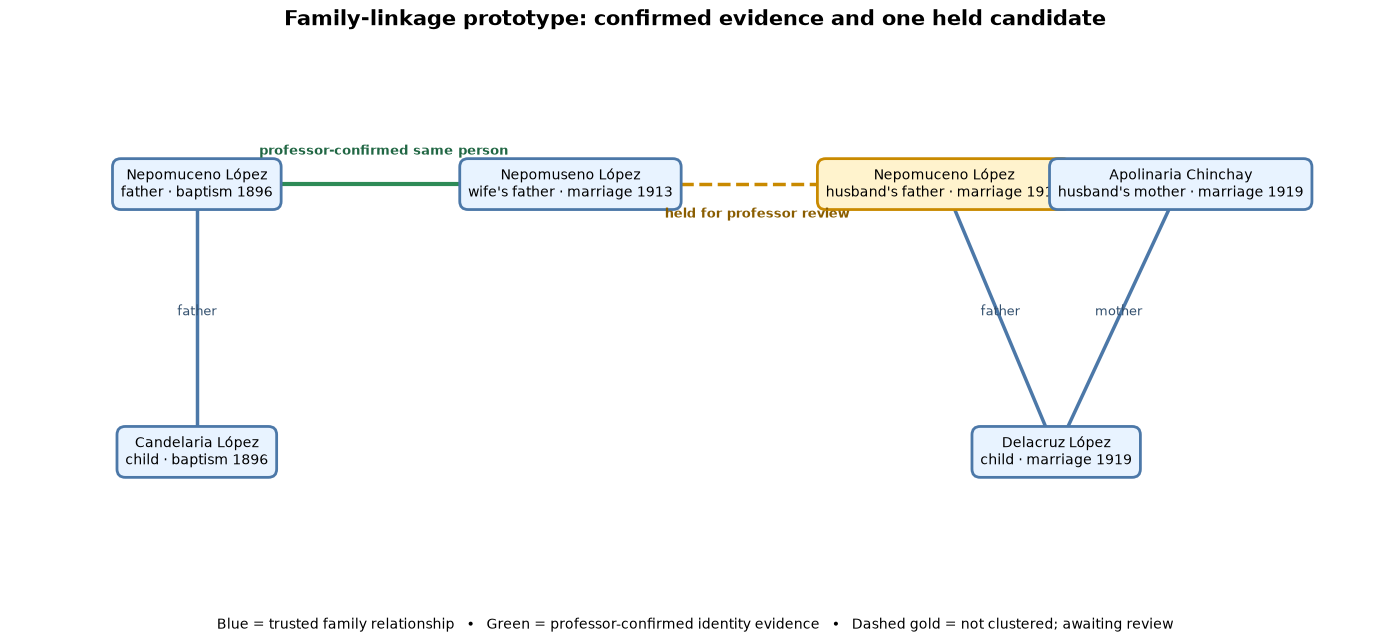

,metric,value
0,trusted_family_relationships_in_prototype,3
1,professor_confirmed_identity_evidence_links,1
2,held_candidates_not_clustered,1
3,automatic_master_cluster_changes,0


Saved presentation tree: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\charts\monday_family_tree_prototype_v1.png
Saved link audit: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\monday_family_tree_prototype_links_v1.csv


In [33]:
# Build a presentation-ready, review-only family-tree prototype

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NEO4J_DIR = PROJECT_ROOT / 'outputs' / 'neo4j'
CHART_DIR = PROJECT_ROOT / 'outputs' / 'charts'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
CHART_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
RELATIONSHIPS_PATH = NEO4J_DIR / 'family_graph_relationships.csv'
NODES_PATH = NEO4J_DIR / 'family_graph_nodes.csv'
TREE_PATH = CHART_DIR / 'monday_family_tree_prototype_v1.png'
EDGE_AUDIT_PATH = REVIEW_DIR / 'monday_family_tree_prototype_links_v1.csv'

assert RELATIONSHIPS_PATH.exists() and NODES_PATH.exists(), 'Existing trusted family-graph exports are required.'
nodes = pd.read_csv(NODES_PATH, dtype=str).fillna('')
relationships = pd.read_csv(RELATIONSHIPS_PATH, dtype=str).fillna('')

# The two explicit parent-child links come from the trusted graph. The identity evidence is professor-confirmed.
trusted_ids = {'HP-00016773', 'HP-00016772', 'HP-00032784', 'HP-00032785', 'HP-00032778'}
trusted = relationships[relationships['source_person_id'].isin(trusted_ids) & relationships['target_person_id'].isin(trusted_ids)].copy()
trusted = trusted[trusted['relationship_type'].isin(['FATHER_OF', 'MOTHER_OF'])].copy()
assert {'HP-00016773', 'HP-00016772', 'HP-00032784', 'HP-00032785', 'HP-00032778'}.issubset(set(nodes['person_id'])), 'Prototype persons are missing from graph nodes.'
assert len(trusted) == 3, f'Expected three trusted family links; found {len(trusted)}.'

prototype_edges = pd.concat([
    trusted.assign(link_status='trusted_graph_relationship', review_status='included_in_prototype'),
    pd.DataFrame([
        {'relationship_id':'PROFESSOR-CONFIRMED-001','source_person_id':'HP-00016773','target_person_id':'HP-00031379','relationship_type':'SAME_PERSON_EVIDENCE','link_status':'professor_confirmed_family_evidence','review_status':'included_in_prototype'},
        {'relationship_id':'HELD-REVIEW-001','source_person_id':'HP-00031379','target_person_id':'HP-00032784','relationship_type':'SAME_PERSON_CANDIDATE','link_status':'held_for_professor_review','review_status':'not_clustered'},
    ])
], ignore_index=True, sort=False)
prototype_edges.to_csv(EDGE_AUDIT_PATH, index=False)

labels = {
    'HP-00016773': 'Nepomuceno López\nfather · baptism 1896',
    'HP-00031379': "Nepomuseno López\nwife's father · marriage 1913",
    'HP-00016772': 'Candelaria López\nchild · baptism 1896',
    'HP-00032784': "Nepomuceno López\nhusband's father · marriage 1919",
    'HP-00032785': "Apolinaria Chinchay\nhusband's mother · marriage 1919",
    'HP-00032778': 'Delacruz López\nchild · marriage 1919',
}
positions = {
    'HP-00016773': (0.0, 2.2), 'HP-00031379': (3.0, 2.2), 'HP-00032784': (6.0, 2.2),
    'HP-00032785': (7.9, 2.2), 'HP-00016772': (0.0, 0.2), 'HP-00032778': (6.9, 0.2),
}
fig, ax = plt.subplots(figsize=(14, 6.5))
for source, target, relation in [('HP-00016773','HP-00016772','father'), ('HP-00032784','HP-00032778','father'), ('HP-00032785','HP-00032778','mother')]:
    ax.plot([positions[source][0], positions[target][0]], [positions[source][1], positions[target][1]], color='#4C78A8', linewidth=2.5, zorder=1)
    ax.text((positions[source][0]+positions[target][0])/2, 1.25, relation, ha='center', va='center', fontsize=9, color='#34516F')
ax.plot([0.0, 3.0], [2.2, 2.2], color='#2E8B57', linewidth=3, zorder=1)
ax.text(1.5, 2.42, 'professor-confirmed same person', ha='center', fontsize=9, color='#216744', fontweight='bold')
ax.plot([3.0, 6.0], [2.2, 2.2], color='#C98A00', linewidth=2.5, linestyle='--', zorder=1)
ax.text(4.5, 1.95, 'held for professor review', ha='center', fontsize=9, color='#8A5D00', fontweight='bold')
for person_id, (x, y) in positions.items():
    held = person_id == 'HP-00032784'
    color = '#FFF3CD' if held else '#E8F3FF'
    edge = '#C98A00' if held else '#4C78A8'
    ax.text(x, y, labels[person_id], ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round,pad=0.6', facecolor=color, edgecolor=edge, linewidth=2), zorder=2)
ax.set_title('Family-linkage prototype: confirmed evidence and one held candidate', fontsize=15, fontweight='bold', pad=18)
ax.text(0.5, -0.08, 'Blue = trusted family relationship   •   Green = professor-confirmed identity evidence   •   Dashed gold = not clustered; awaiting review', transform=ax.transAxes, ha='center', fontsize=10)
ax.set_xlim(-1.5, 9.5); ax.set_ylim(-0.8, 3.2); ax.axis('off')
fig.tight_layout(); fig.savefig(TREE_PATH, dpi=220, bbox_inches='tight'); plt.show(); plt.close(fig)

prototype_summary = pd.DataFrame([
    {'metric':'trusted_family_relationships_in_prototype','value':3},
    {'metric':'professor_confirmed_identity_evidence_links','value':1},
    {'metric':'held_candidates_not_clustered','value':1},
    {'metric':'automatic_master_cluster_changes','value':0},
])
display(prototype_summary)
print(f'Saved presentation tree: {TREE_PATH}')
print(f'Saved link audit: {EDGE_AUDIT_PATH}')


---
## Family-cluster IDs and name lookup

Each person retains their own `person_id`. This section adds a shared `family_cluster_id` to people connected by trusted parent/child/spouse relationships and explicitly professor-confirmed identity evidence. Held candidates are excluded. This is a non-destructive prototype output; it never overwrites the master identities.


In [34]:
# Build reusable family-cluster IDs from trusted graph relationships and confirmed identity evidence

import re
import unicodedata

CLUSTER_MEMBERSHIP_PATH = PROCESSED_DIR / 'family_cluster_membership_prototype_v1.parquet'
CLUSTER_LOOKUP_PATH = REVIEW_DIR / 'family_cluster_name_lookup_prototype_v1.csv'
CLUSTER_SUMMARY_PATH = REPORT_DIR / 'family_cluster_prototype_summary_v1.csv'

nodes = pd.read_csv(NODES_PATH, dtype=str).fillna('').copy()
relationships = pd.read_csv(RELATIONSHIPS_PATH, dtype=str).fillna('').copy()
assert nodes['person_id'].is_unique, 'Family graph nodes must have unique person IDs.'

# Include every persona, even when no trusted relationship has yet been extracted.
# Such people receive a one-person family cluster until future evidence connects them.
all_personas = pd.read_parquet(CONTEXT_PATH).copy()
assert 'persona_idno' in all_personas.columns, 'Enriched persona context is missing persona_idno.'
all_personas['person_id'] = all_personas['persona_idno'].astype(str).str.extract(r'persona-(\d+)', expand=False).astype('Int64').map(lambda x: f'HP-{int(x):08d}' if pd.notna(x) else '')
assert all_personas['person_id'].ne('').all() and all_personas['person_id'].is_unique, 'Persona IDs could not be mapped uniquely to person IDs.'
missing_personas = all_personas[~all_personas['person_id'].isin(nodes['person_id'])].copy()
if not missing_personas.empty:
    fallback_nodes = pd.DataFrame('', index=missing_personas.index, columns=nodes.columns)
    fallback_nodes['person_id'] = missing_personas['person_id']
    fallback_nodes['preferred_name'] = missing_personas['full_name_clean'].fillna('').astype(str) if 'full_name_clean' in missing_personas.columns else ''
    if 'existing_gender_evidence' in missing_personas.columns and 'gender' in fallback_nodes.columns:
        fallback_nodes['gender'] = missing_personas['existing_gender_evidence'].fillna('').astype(str)
    if 'event_year' in missing_personas.columns:
        year_value = pd.to_numeric(missing_personas['event_year'], errors='coerce').astype('Int64').astype(str).replace('<NA>', '')
        for column in ['earliest_year', 'latest_year']:
            if column in fallback_nodes.columns:
                fallback_nodes[column] = year_value
    if 'role_standard' in missing_personas.columns and 'roles' in fallback_nodes.columns:
        fallback_nodes['roles'] = missing_personas['role_standard'].fillna('').astype(str)
    nodes = pd.concat([nodes, fallback_nodes], ignore_index=True)
assert len(nodes) == len(all_personas), 'Family prototype must include every enriched persona exactly once.'

parent = {person_id: person_id for person_id in nodes['person_id']}
def find(person_id):
    while parent[person_id] != person_id:
        parent[person_id] = parent[parent[person_id]]
        person_id = parent[person_id]
    return person_id
def union(left, right):
    left_root, right_root = find(left), find(right)
    if left_root != right_root:
        parent[right_root] = left_root

# Existing family graph is trusted relationship evidence.
trusted_relationships = relationships[relationships['source_person_id'].isin(parent) & relationships['target_person_id'].isin(parent)].copy()
for row in trusted_relationships[['source_person_id', 'target_person_id']].itertuples(index=False):
    union(row.source_person_id, row.target_person_id)

# Add only explicit professor-confirmed identity evidence; never add held candidates.
family_evidence = pd.read_csv(FAMILY_EVIDENCE_PATH, dtype=str).fillna('')
confirmed_pairs = family_evidence[family_evidence['pair_key'].str.strip().ne('')].copy()
def persona_to_person_id(persona_id):
    match = re.fullmatch(r'persona-(\d+)', str(persona_id).strip())
    assert match, f'Unexpected persona ID in professor evidence: {persona_id}'
    return f"HP-{int(match.group(1)):08d}"
for pair_key in confirmed_pairs['pair_key']:
    left, right = pair_key.split('||')
    left_id, right_id = persona_to_person_id(left), persona_to_person_id(right)
    assert left_id in parent and right_id in parent, f'Professor evidence references an unknown graph person: {pair_key}'
    union(left_id, right_id)

roots = {person_id: find(person_id) for person_id in nodes['person_id']}
root_order = sorted(set(roots.values()))
root_to_family = {root: f'FCL-{index:06d}' for index, root in enumerate(root_order, start=1)}
membership = nodes.copy()
membership['family_cluster_id'] = membership['person_id'].map(lambda person_id: root_to_family[roots[person_id]])
membership['family_cluster_source'] = 'trusted_family_graph_plus_professor_confirmed_identity_evidence'
membership['master_identity_changed'] = False
membership.to_parquet(CLUSTER_MEMBERSHIP_PATH, index=False)

def name_key(value):
    value = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii').lower()
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9]+', ' ', value)).strip()
membership['name_search_key'] = membership['preferred_name'].map(name_key)
cluster_sizes = membership.groupby('family_cluster_id')['person_id'].transform('size')
lookup = membership[['name_search_key', 'preferred_name', 'person_id', 'family_cluster_id', 'gender', 'earliest_year', 'latest_year', 'roles']].copy()
lookup['family_member_count'] = cluster_sizes
lookup = lookup.sort_values(['name_search_key', 'family_cluster_id', 'person_id'])
lookup.to_csv(CLUSTER_LOOKUP_PATH, index=False)

summary = pd.DataFrame([
    {'metric':'people_in_family_cluster_prototype','value':len(membership)},
    {'metric':'personas_added_as_singleton_clusters','value':len(missing_personas)},
    {'metric':'family_clusters','value':membership['family_cluster_id'].nunique()},
    {'metric':'largest_family_cluster','value':int(cluster_sizes.max())},
    {'metric':'trusted_graph_relationships_used','value':len(trusted_relationships)},
    {'metric':'professor_confirmed_identity_edges_used','value':len(confirmed_pairs)},
    {'metric':'held_candidates_excluded_from_clusters','value':1},
    {'metric':'master_identity_changes','value':0},
])
summary.to_csv(CLUSTER_SUMMARY_PATH, index=False)
display(summary)
print(f'Saved family-cluster membership: {CLUSTER_MEMBERSHIP_PATH}')
print(f'Saved searchable name lookup: {CLUSTER_LOOKUP_PATH}')


,metric,value
0,people_in_family_cluster_prototype,47072
1,personas_added_as_singleton_clusters,7925
2,family_clusters,31089
3,largest_family_cluster,14
4,trusted_graph_relationships_used,16281
5,professor_confirmed_identity_edges_used,1
6,held_candidates_excluded_from_clusters,1
7,master_identity_changes,0


Saved family-cluster membership: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\family_cluster_membership_prototype_v1.parquet
Saved searchable name lookup: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\family_cluster_name_lookup_prototype_v1.csv


In [35]:
# Search a name and return every member of each matching family cluster
# Change this value for the Monday demonstration.
SEARCH_NAME = 'nepomuceno lopez'

membership = pd.read_parquet(CLUSTER_MEMBERSHIP_PATH).copy()
membership['name_search_key'] = membership['preferred_name'].map(name_key)
matches = membership[membership['name_search_key'].eq(name_key(SEARCH_NAME))].copy()
assert not matches.empty, f'No person found for: {SEARCH_NAME}'
matched_cluster_ids = sorted(matches['family_cluster_id'].unique())
family_tree_result = membership[membership['family_cluster_id'].isin(matched_cluster_ids)].copy()
family_tree_result = family_tree_result.sort_values(['family_cluster_id', 'earliest_year', 'preferred_name'])
display(matches[['person_id', 'preferred_name', 'family_cluster_id', 'roles', 'earliest_year', 'latest_year']])
display(family_tree_result[['family_cluster_id', 'person_id', 'preferred_name', 'gender', 'earliest_year', 'latest_year', 'roles']])
print(f"Found {len(matches)} matching person record(s) across {len(matched_cluster_ids)} verified family cluster(s), containing {len(family_tree_result)} people.")


,person_id,preferred_name,family_cluster_id,roles,earliest_year,latest_year
13236,HP-00016773,nepomuceno lopez,FCL-011336,father,1896,1896
26966,HP-00032784,nepomuceno lopez,FCL-021943,husband_father,1919,1919


,family_cluster_id,person_id,preferred_name,gender,earliest_year,latest_year,roles
13237,FCL-011336,HP-00016774,apolonia chinchai,,1896,1896,mother
13235,FCL-011336,HP-00016772,candelaria lopez,,1896,1896,baptized
13236,FCL-011336,HP-00016773,nepomuceno lopez,,1896,1896,father
25662,FCL-011336,HP-00031379,nepomuseno lopez,,1913,1913,wife_father
26967,FCL-021943,HP-00032785,apolinaria chinchay,,1919,1919,husband_mother
26960,FCL-021943,HP-00032778,delacruz lopez,,1919,1919,husband
26969,FCL-021943,HP-00032787,leocadia mancco,,1919,1919,wife_mother
26966,FCL-021943,HP-00032784,nepomuceno lopez,,1919,1919,husband_father
26961,FCL-021943,HP-00032779,petronila leon,,1919,1919,wife
26968,FCL-021943,HP-00032786,rodesindo leon,,1919,1919,wife_father


Found 2 matching person record(s) across 2 verified family cluster(s), containing 10 people.


---
## Small professor verification package

This export contains two compact cases: a repeated-name family that should share one FCL, and a different family with the same name that should remain separate. It is a review aid only and makes no changes to clusters.


In [36]:
# Export a concise FCL verification sample for the professor

PROFESSOR_FCL_SAMPLE_PATH = REVIEW_DIR / 'professor_family_cluster_verification_sample_v1.csv'
membership = pd.read_parquet(CLUSTER_MEMBERSHIP_PATH).copy()
sample_specs = [
    ('A_same_family_repeated_name', 'The two Nieves Guillen records have the same parents across 1898 and 1904, so every related person should share FCL-026347.', 'FCL-026347'),
    ('B_same_name_different_family', 'This 1894 Nieves Guillen has different parents and should remain separate in FCL-028968.', 'FCL-028968'),
]
samples = []
for sample_case, verification_question, family_cluster_id in sample_specs:
    case_rows = membership[membership['family_cluster_id'].eq(family_cluster_id)].copy()
    assert not case_rows.empty, f'Missing expected verification cluster: {family_cluster_id}'
    case_rows['sample_case'] = sample_case
    case_rows['verification_question'] = verification_question
    samples.append(case_rows)
professor_sample = pd.concat(samples, ignore_index=True)
columns = ['sample_case', 'verification_question', 'family_cluster_id', 'person_id', 'preferred_name', 'gender', 'earliest_year', 'latest_year', 'roles', 'family_component_id', 'family_component_size']
columns = [column for column in columns if column in professor_sample.columns]
professor_sample = professor_sample[columns].sort_values(['sample_case', 'earliest_year', 'preferred_name', 'person_id'])
assert professor_sample.groupby('sample_case')['family_cluster_id'].nunique().eq(1).all(), 'Each review case must contain exactly one FCL.'
professor_sample.to_csv(PROFESSOR_FCL_SAMPLE_PATH, index=False)
display(professor_sample)
print(f'Saved {len(professor_sample)} review rows: {PROFESSOR_FCL_SAMPLE_PATH}')
print('Professor question: confirm that Case A is one family and Case B is a different family despite the repeated name.')


,sample_case,verification_question,family_cluster_id,person_id,preferred_name,gender,earliest_year,latest_year,roles,family_component_id,family_component_size
0,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039432,gaspar huarcaya,,1898,1898,husband,FAM-005902,9
4,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039441,juan de dios guillen,,1898,1904,wife_father,FAM-005902,9
5,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039442,manuela oscco,,1898,1904,wife_mother,FAM-005902,9
1,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039433,nieves guillen,,1898,1898,wife,FAM-005902,9
2,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039439,santiago huarcaya,,1898,1898,husband_father,FAM-005902,9
3,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00039440,yldefonza chaves,,1898,1898,husband_mother,FAM-005902,9
6,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00040736,anaclo huaman,,1904,1904,husband,FAM-005902,9
8,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00040743,jenoveva huarcaya,,1904,1904,husband_mother,FAM-005902,9
7,A_same_family_repeated_name,The two Nieves Guillen records have the same p...,FCL-026347,HP-00040737,nieves guillen,,1904,1904,wife,FAM-005902,9
10,B_same_name_different_family,This 1894 Nieves Guillen has different parents...,FCL-028968,HP-00043486,bartolome guillen,,1894,1894,father,FAM-006436,3


Saved 12 review rows: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\professor_family_cluster_verification_sample_v1.csv
Professor question: confirm that Case A is one family and Case B is a different family despite the repeated name.


---
## Identity-aware family clusters (v2)

This scalable layer uses the existing safe identity clusters as person nodes, then joins those people through trusted family relationships. It preserves every source persona and never creates a new identity merge. Personas without a safe identity assignment remain separate provisional people.


In [37]:
# Build identity-aware family-cluster membership without modifying safe identity clusters

import re
import unicodedata

SAFE_IDENTITY_PATH = PROCESSED_DIR / 'identity_cluster_membership_final_safe.parquet'
IDENTITY_FAMILY_MEMBERSHIP_PATH = PROCESSED_DIR / 'identity_aware_family_cluster_membership_v2.parquet'
IDENTITY_FAMILY_LOOKUP_PATH = REVIEW_DIR / 'identity_aware_family_cluster_lookup_v2.csv'
IDENTITY_FAMILY_SUMMARY_PATH = REPORT_DIR / 'identity_aware_family_cluster_summary_v2.csv'

assert SAFE_IDENTITY_PATH.exists(), f'Missing safe identity membership: {SAFE_IDENTITY_PATH}'
assert NODES_PATH.exists() and RELATIONSHIPS_PATH.exists(), 'Trusted family-graph exports are required.'

context_columns = [
    'persona_idno', 'full_name_clean', 'first_name_canonical_key', 'lastname_canonical_key',
    'parent_pair_clean', 'spouse_name_clean_ctx', 'event_place_linkage_key',
    'event_key', 'event_year', 'role_standard', 'existing_gender_evidence',
]
all_personas = pd.read_parquet(CONTEXT_PATH, columns=context_columns).copy()
all_personas['persona_idno'] = all_personas['persona_idno'].astype(str)
assert all_personas['persona_idno'].is_unique, 'Enriched context must contain one row per persona.'

safe_identity = pd.read_parquet(SAFE_IDENTITY_PATH, columns=['persona_idno', 'final_cluster_id', 'final_historical_person_id', 'final_cluster_size', 'final_cluster_status']).copy()
safe_identity['persona_idno'] = safe_identity['persona_idno'].astype(str)
assert safe_identity['persona_idno'].is_unique, 'Safe identity membership contains duplicate personas.'
assert safe_identity['final_cluster_id'].notna().all() and safe_identity['final_historical_person_id'].notna().all(), 'Safe identity membership contains blank final IDs.'

membership_v2 = all_personas.merge(safe_identity, on='persona_idno', how='left', validate='1:1')
membership_v2['identity_cluster_source'] = np.where(membership_v2['final_cluster_id'].notna(), 'safe_final_identity_cluster', 'provisional_singleton_no_safe_identity')
membership_v2['identity_cluster_id'] = membership_v2['final_cluster_id'].fillna('PROV-' + membership_v2['persona_idno'])
membership_v2['identity_person_id'] = membership_v2['final_historical_person_id'].fillna('PROV-' + membership_v2['persona_idno'])
assert len(membership_v2) == len(all_personas), 'Identity-aware membership changed persona row count.'
assert membership_v2.groupby('identity_cluster_id')['identity_person_id'].nunique().le(1).all(), 'An identity cluster maps to multiple person IDs.'

# Family links operate between existing safe identity persons; no relationship creates a new identity merge.
relationship_edges = pd.read_csv(RELATIONSHIPS_PATH, dtype=str).fillna('')
identity_people = set(membership_v2['identity_person_id'])
parent = {person_id: person_id for person_id in identity_people}
def find_identity(person_id):
    while parent[person_id] != person_id:
        parent[person_id] = parent[parent[person_id]]
        person_id = parent[person_id]
    return person_id
def union_family(left, right):
    left_root, right_root = find_identity(left), find_identity(right)
    if left_root != right_root:
        parent[right_root] = left_root

trusted_edges = relationship_edges[relationship_edges['source_person_id'].isin(identity_people) & relationship_edges['target_person_id'].isin(identity_people)].copy()
for edge in trusted_edges[['source_person_id', 'target_person_id']].itertuples(index=False):
    union_family(edge.source_person_id, edge.target_person_id)

identity_roots = {person_id: find_identity(person_id) for person_id in identity_people}
root_order = sorted(set(identity_roots.values()))
root_to_fcl = {root: f'FCL2-{index:06d}' for index, root in enumerate(root_order, start=1)}
membership_v2['family_cluster_id'] = membership_v2['identity_person_id'].map(lambda person_id: root_to_fcl[identity_roots[person_id]])
membership_v2['automatic_identity_cluster_change'] = False

def clean_name_key(value):
    value = unicodedata.normalize('NFKD', str(value)).encode('ascii', 'ignore').decode('ascii').lower()
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z0-9]+', ' ', value)).strip()

# One lookup row per identity person prevents repeated source records from appearing as separate people in a family tree.
membership_v2['event_year_numeric'] = pd.to_numeric(membership_v2['event_year'], errors='coerce')
identity_lookup = (
    membership_v2.sort_values(['identity_person_id', 'event_year_numeric', 'persona_idno'])
    .groupby(['identity_person_id', 'identity_cluster_id', 'family_cluster_id', 'identity_cluster_source'], as_index=False)
    .agg(
        preferred_name=('full_name_clean', 'first'),
        gender=('existing_gender_evidence', 'first'),
        earliest_year=('event_year_numeric', 'min'),
        latest_year=('event_year_numeric', 'max'),
        source_persona_count=('persona_idno', 'size'),
        roles=('role_standard', lambda values: ' | '.join(sorted({str(value) for value in values if str(value).strip()}))),
    )
)
identity_lookup['name_search_key'] = identity_lookup['preferred_name'].map(clean_name_key)
identity_lookup['family_member_count'] = identity_lookup.groupby('family_cluster_id')['identity_person_id'].transform('size')

assert membership_v2['automatic_identity_cluster_change'].eq(False).all()
assert membership_v2['family_cluster_id'].notna().all()
membership_v2.to_parquet(IDENTITY_FAMILY_MEMBERSHIP_PATH, index=False)
identity_lookup.sort_values(['name_search_key', 'family_cluster_id', 'identity_person_id']).to_csv(IDENTITY_FAMILY_LOOKUP_PATH, index=False)

summary_v2 = pd.DataFrame([
    {'metric':'input_personas','value':len(all_personas)},
    {'metric':'safe_identity_memberships_reused','value':int(membership_v2['identity_cluster_source'].eq('safe_final_identity_cluster').sum())},
    {'metric':'provisional_singleton_personas','value':int(membership_v2['identity_cluster_source'].eq('provisional_singleton_no_safe_identity').sum())},
    {'metric':'identity_people','value':len(identity_lookup)},
    {'metric':'identity_aware_family_clusters','value':membership_v2['family_cluster_id'].nunique()},
    {'metric':'trusted_family_relationships_used','value':len(trusted_edges)},
    {'metric':'automatic_identity_cluster_changes','value':0},
])
summary_v2.to_csv(IDENTITY_FAMILY_SUMMARY_PATH, index=False)
display(summary_v2)
print(f'Saved identity-aware membership: {IDENTITY_FAMILY_MEMBERSHIP_PATH}')
print(f'Saved identity-aware lookup: {IDENTITY_FAMILY_LOOKUP_PATH}')


,metric,value
0,input_personas,47072
1,safe_identity_memberships_reused,41251
2,provisional_singleton_personas,5821
3,identity_people,44995
4,identity_aware_family_clusters,29013
5,trusted_family_relationships_used,16281
6,automatic_identity_cluster_changes,0


Saved identity-aware membership: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\identity_aware_family_cluster_membership_v2.parquet
Saved identity-aware lookup: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\identity_aware_family_cluster_lookup_v2.csv


In [38]:
# Search the identity-aware family graph: one row per person, not one row per source record
SEARCH_NAME_V2 = 'nieves guillen'

identity_lookup = pd.read_csv(IDENTITY_FAMILY_LOOKUP_PATH, dtype=str).fillna('')
matches_v2 = identity_lookup[identity_lookup['name_search_key'].eq(clean_name_key(SEARCH_NAME_V2))].copy()
assert not matches_v2.empty, f'No identity-aware family match found for: {SEARCH_NAME_V2}'
selected_fcls_v2 = sorted(matches_v2['family_cluster_id'].unique())
family_tree_v2 = identity_lookup[identity_lookup['family_cluster_id'].isin(selected_fcls_v2)].copy()
family_tree_v2 = family_tree_v2.sort_values(['family_cluster_id', 'earliest_year', 'preferred_name'])
display(matches_v2[['identity_person_id', 'preferred_name', 'identity_cluster_id', 'family_cluster_id', 'source_persona_count', 'roles']])
display(family_tree_v2[['family_cluster_id', 'identity_person_id', 'preferred_name', 'gender', 'earliest_year', 'latest_year', 'source_persona_count', 'roles']])
print(f"Found {len(matches_v2)} matching identity person(s) across {len(selected_fcls_v2)} family cluster(s), containing {len(family_tree_v2)} identity people.")


,identity_person_id,preferred_name,identity_cluster_id,family_cluster_id,source_persona_count,roles
32865,HP-00039433,nieves guillen,FC034949,FCL2-019944,1,wife
32866,HP-00040737,nieves guillen,FC036177,FCL2-019944,1,wife
32867,HP-00043485,nieves guillen,FC038348,FCL2-021847,1,deceased


,family_cluster_id,identity_person_id,preferred_name,gender,earliest_year,latest_year,source_persona_count,roles
15192,FCL2-019944,HP-00039432,gaspar huarcaya,male,1898,1898,1,husband
19214,FCL2-019944,HP-00039441,juan de dios guillen,male,1898,1904,2,wife_father
25388,FCL2-019944,HP-00039442,manuela oscco,female,1898,1904,2,wife_mother
32865,FCL2-019944,HP-00039433,nieves guillen,female,1898,1898,1,wife
38267,FCL2-019944,HP-00039439,santiago huarcaya,male,1898,1898,1,husband_father
44175,FCL2-019944,HP-00039440,yldefonza chaves,unknown,1898,1898,1,husband_mother
1255,FCL2-019944,HP-00040736,anaclo huaman,unknown,1904,1904,1,husband
17273,FCL2-019944,HP-00040743,jenoveva huarcaya,unknown,1904,1904,1,husband_mother
32866,FCL2-019944,HP-00040737,nieves guillen,female,1904,1904,1,wife
4154,FCL2-021847,HP-00043486,bartolome guillen,unknown,1894,1894,1,father


Found 3 matching identity person(s) across 2 family cluster(s), containing 12 identity people.


---
## Within-family identity-link review queue

This finds separate safe identities inside one family cluster that may be the same individual. It produces a ranked review queue only; no candidate is merged automatically.


In [39]:
# Propose likely duplicate identities within an FCL for structured review

from itertools import combinations

WITHIN_FAMILY_QUEUE_PATH = REVIEW_DIR / 'within_family_identity_link_review_queue_v1.csv'
WITHIN_FAMILY_SUMMARY_PATH = REPORT_DIR / 'within_family_identity_link_review_summary_v1.csv'
membership_v2 = pd.read_parquet(IDENTITY_FAMILY_MEMBERSHIP_PATH).copy()
required_within_family_columns = {
    'identity_person_id', 'identity_cluster_id', 'family_cluster_id', 'full_name_clean',
    'first_name_canonical_key', 'lastname_canonical_key', 'parent_pair_clean',
    'spouse_name_clean_ctx', 'event_place_linkage_key', 'event_year', 'event_key', 'role_standard',
}
missing_within_family = required_within_family_columns - set(membership_v2.columns)
assert not missing_within_family, f'Identity-aware membership needs refreshed fields: {sorted(missing_within_family)}'

def nonblank_set(values):
    return {str(value).strip() for value in values if pd.notna(value) and str(value).strip() and str(value).strip().lower() != 'unknown'}

membership_v2['canonical_full_name_key'] = (
    membership_v2['first_name_canonical_key'].fillna('').astype(str).str.strip() + ' ' +
    membership_v2['lastname_canonical_key'].fillna('').astype(str).str.strip()
).str.strip()
membership_v2['event_year_numeric'] = pd.to_numeric(membership_v2['event_year'], errors='coerce')

profiles = []
for keys, group in membership_v2.groupby(['identity_person_id', 'identity_cluster_id', 'family_cluster_id'], sort=False):
    years = group['event_year_numeric'].dropna()
    canonical_names = nonblank_set(group['canonical_full_name_key'])
    profiles.append({
        'identity_person_id': keys[0],
        'identity_cluster_id': keys[1],
        'family_cluster_id': keys[2],
        'preferred_name': next(iter(nonblank_set(group['full_name_clean'])), ''),
        'canonical_full_name_key': sorted(canonical_names)[0] if len(canonical_names) == 1 else '',
        'parent_pairs': nonblank_set(group['parent_pair_clean']),
        'spouse_names': nonblank_set(group['spouse_name_clean_ctx']),
        'place_keys': nonblank_set(group['event_place_linkage_key']),
        'event_keys': nonblank_set(group['event_key']),
        'roles': nonblank_set(group['role_standard']),
        'year_min': years.min() if not years.empty else pd.NA,
        'year_max': years.max() if not years.empty else pd.NA,
        'source_persona_count': len(group),
    })
profiles = pd.DataFrame(profiles)

candidate_rows = []
for (_, canonical_name), group in profiles[profiles['canonical_full_name_key'].ne('')].groupby(['family_cluster_id', 'canonical_full_name_key'], sort=False):
    if len(group) < 2:
        continue
    for left, right in combinations(group.to_dict('records'), 2):
        shared_parents = left['parent_pairs'] & right['parent_pairs']
        shared_spouses = left['spouse_names'] & right['spouse_names']
        shared_places = left['place_keys'] & right['place_keys']
        shared_events = left['event_keys'] & right['event_keys']
        if pd.notna(left['year_min']) and pd.notna(right['year_min']):
            year_gap = max(0, max(left['year_min'], right['year_min']) - min(left['year_max'], right['year_max']))
        else:
            year_gap = pd.NA
        time_compatible = pd.notna(year_gap) and year_gap <= 30
        # Require family or place context beyond a shared name; same-event pairs are held back.
        contextual_support = bool(shared_parents or shared_spouses or shared_places)
        same_event_overlap = bool(shared_events)
        if not contextual_support or same_event_overlap:
            continue
        score = 3 * int(bool(shared_parents)) + 2 * int(bool(shared_spouses)) + int(bool(shared_places)) + int(time_compatible)
        candidate_rows.append({
            'pair_key': '||'.join(sorted([left['identity_person_id'], right['identity_person_id']])),
            'family_cluster_id': left['family_cluster_id'],
            'identity_person_id_l': left['identity_person_id'],
            'identity_person_id_r': right['identity_person_id'],
            'preferred_name_l': left['preferred_name'],
            'preferred_name_r': right['preferred_name'],
            'canonical_full_name_key': canonical_name,
            'shared_parent_pair': ' | '.join(sorted(shared_parents)),
            'shared_spouse_name': ' | '.join(sorted(shared_spouses)),
            'shared_place_key': ' | '.join(sorted(shared_places)),
            'event_year_gap': year_gap,
            'time_compatible_within_30_years': bool(time_compatible),
            'same_event_overlap_excluded': False,
            'support_score': score,
            'review_priority': 'high' if score >= 4 else 'standard',
            'review_decision': 'unreviewed',
            'automatic_identity_cluster_change': False,
        })

within_family_queue = pd.DataFrame(candidate_rows)
if within_family_queue.empty:
    within_family_queue = pd.DataFrame(columns=['pair_key', 'family_cluster_id', 'identity_person_id_l', 'identity_person_id_r', 'preferred_name_l', 'preferred_name_r', 'canonical_full_name_key', 'shared_parent_pair', 'shared_spouse_name', 'shared_place_key', 'event_year_gap', 'time_compatible_within_30_years', 'same_event_overlap_excluded', 'support_score', 'review_priority', 'review_decision', 'automatic_identity_cluster_change'])
else:
    assert within_family_queue['pair_key'].is_unique, 'Within-family review queue contains duplicate pairs.'
    assert within_family_queue['automatic_identity_cluster_change'].eq(False).all()
    within_family_queue = within_family_queue.sort_values(['support_score', 'event_year_gap'], ascending=[False, True], na_position='last').reset_index(drop=True)

within_family_queue.to_csv(WITHIN_FAMILY_QUEUE_PATH, index=False)
within_family_summary = pd.DataFrame([
    {'metric':'identity_people_considered','value':len(profiles)},
    {'metric':'within_family_identity_candidates','value':len(within_family_queue)},
    {'metric':'high_priority_candidates','value':int(within_family_queue['review_priority'].eq('high').sum())},
    {'metric':'automatic_identity_cluster_changes','value':0},
])
within_family_summary.to_csv(WITHIN_FAMILY_SUMMARY_PATH, index=False)
display(within_family_summary)
display(within_family_queue.head(30))
print(f'Saved within-family identity review queue: {WITHIN_FAMILY_QUEUE_PATH}')


,metric,value
0,identity_people_considered,44995
1,within_family_identity_candidates,58
2,high_priority_candidates,27
3,automatic_identity_cluster_changes,0


,pair_key,family_cluster_id,identity_person_id_l,identity_person_id_r,preferred_name_l,preferred_name_r,canonical_full_name_key,shared_parent_pair,shared_spouse_name,shared_place_key,event_year_gap,time_compatible_within_30_years,same_event_overlap_excluded,support_score,review_priority,review_decision,automatic_identity_cluster_change
0,HP-00021780||HP-00021888,FCL2-010124,HP-00021780,HP-00021888,inosencia ccoyllo,ynosencia ccoyllo,ynocencia ccoillo,juan ccoyllo|benita cucho,,aucara,0,True,False,5,high,unreviewed,False
1,HP-00021812||HP-00021920,FCL2-010138,HP-00021812,HP-00021920,estevan ramos,esteban ramos,estevan ramos,pablo ramos|rufina,,aucara,0,True,False,5,high,unreviewed,False
2,HP-00031789||HP-00033107,FCL2-015633,HP-00031789,HP-00033107,petronila vivanco,petronila vivanco,petronila vivanco,fernando vivanco|bernabe chinchay,,aucara,1,True,False,5,high,unreviewed,False
3,HP-00024779||HP-00031519,FCL2-015487,HP-00024779,HP-00031519,leon bautista,leon bautista,leon bautista,celedonio bautista|eduarda sanchez,,pampamarca,2,True,False,5,high,unreviewed,False
4,HP-00031858||HP-00032798,FCL2-016154,HP-00031858,HP-00032798,daniel bautista,daniel bautista,daniel bautista,celedonio bautista|eduarda sanchez,,pampamarca,2,True,False,5,high,unreviewed,False
5,HP-00031480||HP-00040797,FCL2-015467,HP-00031480,HP-00040797,juliana berrocal,juliana berrocal,juliana berrocal,patricio berrocal|benita ochoa,,aucara,3,True,False,5,high,unreviewed,False
6,HP-00017181||HP-00018270,FCL2-008006,HP-00017181,HP-00018270,estefa polanco,estefa polanco,estefa polanco,eustaquio polanco|ignacia bustillos,,aucara,5,True,False,5,high,unreviewed,False
7,HP-00039433||HP-00040737,FCL2-019944,HP-00039433,HP-00040737,nieves guillen,nieves guillen,nieves guillen,juan de dios guillen|manuela oscco,,aucara,6,True,False,5,high,unreviewed,False
8,HP-00039131||HP-00040606,FCL2-020553,HP-00039131,HP-00040606,mariano serrano,mariano serrano,mariano serrano,nicolas serrano|juana urbano,,chacralla iglesia vice parroquial,8,True,False,5,high,unreviewed,False
9,HP-00032709||HP-00039492,FCL2-016112,HP-00032709,HP-00039492,cecilia cucho,cecilia cucho,cecilia cucho,jose cucho|felipa gavilan,,aucara,20,True,False,5,high,unreviewed,False


Saved within-family identity review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\within_family_identity_link_review_queue_v1.csv


---
## Gramps family-tree test export

This produces one small GEDCOM file for an identity-aware FCL. Import it into the open-source Gramps application to inspect the family tree visually before accepting any proposed identity link.


In [40]:
# Export one identity-aware family cluster as a small Gramps-compatible GEDCOM test tree

from pathlib import Path
import re
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').is_dir():
    raise FileNotFoundError(f'Could not locate the project root from: {Path.cwd()}')
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
IDENTITY_FAMILY_LOOKUP_PATH = REVIEW_DIR / 'identity_aware_family_cluster_lookup_v2.csv'
RELATIONSHIPS_PATH = PROJECT_ROOT / 'outputs' / 'neo4j' / 'family_graph_relationships.csv'
assert IDENTITY_FAMILY_LOOKUP_PATH.exists(), f'Missing identity-aware lookup: {IDENTITY_FAMILY_LOOKUP_PATH}'
assert RELATIONSHIPS_PATH.exists(), f'Missing trusted family relationships: {RELATIONSHIPS_PATH}'

GRAMPS_DIR = PROJECT_ROOT / 'outputs' / 'gramps'
GRAMPS_DIR.mkdir(parents=True, exist_ok=True)
TEST_FAMILY_CLUSTER_ID = 'FCL2-019944'  # Change to inspect a different FCL.
GED_PATH = GRAMPS_DIR / 'identity_aware_family_tree_test_v2.ged'
GED_AUDIT_PATH = REVIEW_DIR / 'identity_aware_family_tree_test_v2_audit.csv'

identity_lookup = pd.read_csv(IDENTITY_FAMILY_LOOKUP_PATH, dtype=str).fillna('')
tree_people = identity_lookup[identity_lookup['family_cluster_id'].eq(TEST_FAMILY_CLUSTER_ID)].copy()
assert not tree_people.empty, f'Unknown family cluster: {TEST_FAMILY_CLUSTER_ID}'
assert tree_people['identity_person_id'].is_unique, 'GEDCOM export requires one row per identity person.'
person_ids = set(tree_people['identity_person_id'])
relationships = pd.read_csv(RELATIONSHIPS_PATH, dtype=str).fillna('')
tree_relationships = relationships[relationships['source_person_id'].isin(person_ids) & relationships['target_person_id'].isin(person_ids)].copy()

def ged_value(value):
    return re.sub(r'[\r\n]+', ' ', str(value)).replace('@', '').strip()
def ged_name(value):
    parts = ged_value(value).split()
    if len(parts) <= 1:
        return ged_value(value)
    return f"{' '.join(parts[:-1])} /{parts[-1]}/"

xref = {person_id: f'@I{index}@' for index, person_id in enumerate(tree_people['identity_person_id'], start=1)}
lines = ['0 HEAD', '1 SOUR Sondondo identity-aware family prototype', '1 GEDC', '2 VERS 5.5.1', '1 CHAR UTF-8']
for row in tree_people.itertuples(index=False):
    lines.extend([
        f'0 {xref[row.identity_person_id]} INDI',
        f'1 NAME {ged_name(row.preferred_name)}',
        '1 SEX ' + ({'m': 'M', 'male': 'M', 'f': 'F', 'female': 'F'}.get(str(row.gender).lower(), 'U')),
        f'1 NOTE Identity person: {ged_value(row.identity_person_id)}; identity cluster: {ged_value(row.identity_cluster_id)}; family cluster: {ged_value(row.family_cluster_id)}; source personas: {ged_value(row.source_persona_count)}',
    ])
    if str(row.earliest_year).strip():
        lines.extend(['1 EVEN', '2 TYPE Observed record range', f'2 DATE {ged_value(row.earliest_year)}-{ged_value(row.latest_year or row.earliest_year)}'])

parent_edges = tree_relationships[tree_relationships['relationship_type'].isin(['FATHER_OF', 'MOTHER_OF'])].copy()
parent_map = {}
for edge in parent_edges.itertuples(index=False):
    parent_map.setdefault(edge.target_person_id, {})[edge.relationship_type] = edge.source_person_id
family_number = 1
exported_family_keys = set()
for child_id, parents in parent_map.items():
    father_id, mother_id = parents.get('FATHER_OF', ''), parents.get('MOTHER_OF', '')
    family_key = (father_id, mother_id, child_id)
    if family_key in exported_family_keys:
        continue
    exported_family_keys.add(family_key)
    lines.append(f'0 @F{family_number}@ FAM')
    if father_id:
        lines.append(f'1 HUSB {xref[father_id]}')
    if mother_id:
        lines.append(f'1 WIFE {xref[mother_id]}')
    lines.append(f'1 CHIL {xref[child_id]}')
    family_number += 1

for edge in tree_relationships[tree_relationships['relationship_type'].eq('SPOUSE_OF')].itertuples(index=False):
    pair = tuple(sorted([edge.source_person_id, edge.target_person_id]))
    if pair in exported_family_keys:
        continue
    exported_family_keys.add(pair)
    lines.extend([f'0 @F{family_number}@ FAM', f'1 HUSB {xref[pair[0]]}', f'1 WIFE {xref[pair[1]]}', '1 NOTE Trusted spouse relationship'])
    family_number += 1
lines.append('0 TRLR')
GED_PATH.write_text('\n'.join(lines) + '\n', encoding='utf-8')

tree_audit = pd.concat([
    tree_people.assign(audit_type='identity_person'),
    tree_relationships.assign(audit_type='trusted_relationship'),
], ignore_index=True, sort=False)
tree_audit.to_csv(GED_AUDIT_PATH, index=False)
print(f'GEDCOM test tree saved: {GED_PATH}')
print(f'People: {len(tree_people)} | trusted relationships: {len(tree_relationships)} | GEDCOM families: {family_number - 1}')
print('In Gramps: create a new empty tree, then import this GEDCOM as UTF-8.')


GEDCOM test tree saved: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\gramps\identity_aware_family_tree_test_v2.ged
People: 9 | trusted relationships: 9 | GEDCOM families: 6
In Gramps: create a new empty tree, then import this GEDCOM as UTF-8.


### GEDCOM reciprocal-link fix

This corrected export writes both the family-to-person and person-to-family references required by Gramps.


In [41]:
# Write a fully reciprocal GEDCOM: FAM records point to people and people point back to FAM records

from pathlib import Path
import re
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
GRAMPS_DIR = PROJECT_ROOT / 'outputs' / 'gramps'
LOOKUP_PATH = REVIEW_DIR / 'identity_aware_family_cluster_lookup_v2.csv'
RELATIONSHIPS_PATH = PROJECT_ROOT / 'outputs' / 'neo4j' / 'family_graph_relationships.csv'
GED_PATH = GRAMPS_DIR / 'identity_aware_family_tree_test_v2.ged'
GED_AUDIT_PATH = REVIEW_DIR / 'identity_aware_family_tree_test_v2_audit.csv'
TEST_FAMILY_CLUSTER_ID = 'FCL2-019944'
assert LOOKUP_PATH.exists() and RELATIONSHIPS_PATH.exists(), 'Run the identity-aware family-cluster section before this export.'

people = pd.read_csv(LOOKUP_PATH, dtype=str).fillna('')
people = people[people['family_cluster_id'].eq(TEST_FAMILY_CLUSTER_ID)].copy()
assert not people.empty and people['identity_person_id'].is_unique
person_ids = set(people['identity_person_id'])
relationships = pd.read_csv(RELATIONSHIPS_PATH, dtype=str).fillna('')
relationships = relationships[relationships['source_person_id'].isin(person_ids) & relationships['target_person_id'].isin(person_ids)].copy()

def ged_value(value):
    return re.sub(r'[\r\n]+', ' ', str(value)).replace('@', '').strip()
def ged_name(value):
    parts = ged_value(value).split()
    return ged_value(value) if len(parts) <= 1 else f"{' '.join(parts[:-1])} /{parts[-1]}/"

xref = {person_id: f'@I{index}@' for index, person_id in enumerate(people['identity_person_id'], start=1)}
gender = people.set_index('identity_person_id')['gender'].astype(str).str.lower().to_dict()
family_records = []
parent_edges = relationships[relationships['relationship_type'].isin(['FATHER_OF', 'MOTHER_OF'])]
parents_by_child = {}
for edge in parent_edges.itertuples(index=False):
    parents_by_child.setdefault(edge.target_person_id, {})[edge.relationship_type] = edge.source_person_id
for child_id, parent_roles in parents_by_child.items():
    family_records.append({'father': parent_roles.get('FATHER_OF', ''), 'mother': parent_roles.get('MOTHER_OF', ''), 'children': [child_id], 'note': 'Trusted parent-child relationship'})

existing_spouse_pairs = {tuple(sorted(filter(None, [record['father'], record['mother']]))) for record in family_records if record['father'] and record['mother']}
for edge in relationships[relationships['relationship_type'].eq('SPOUSE_OF')].itertuples(index=False):
    pair = tuple(sorted([edge.source_person_id, edge.target_person_id]))
    if pair in existing_spouse_pairs:
        continue
    left, right = pair
    if gender.get(left) in {'f', 'female'} and gender.get(right) in {'m', 'male'}:
        father, mother = right, left
    else:
        father, mother = left, right
    family_records.append({'father': father, 'mother': mother, 'children': [], 'note': 'Trusted spouse relationship'})

family_refs = {person_id: {'FAMC': [], 'FAMS': []} for person_id in person_ids}
for number, record in enumerate(family_records, start=1):
    record['xref'] = f'@F{number}@'
    for parent_id in [record['father'], record['mother']]:
        if parent_id:
            family_refs[parent_id]['FAMS'].append(record['xref'])
    for child_id in record['children']:
        family_refs[child_id]['FAMC'].append(record['xref'])

lines = ['0 HEAD', '1 SOUR Sondondo identity-aware family prototype', '1 GEDC', '2 VERS 5.5.1', '1 CHAR UTF-8']
for row in people.itertuples(index=False):
    lines.extend([f'0 {xref[row.identity_person_id]} INDI', f'1 NAME {ged_name(row.preferred_name)}', '1 SEX ' + ({'m':'M','male':'M','f':'F','female':'F'}.get(str(row.gender).lower(), 'U')), f'1 NOTE Identity person: {ged_value(row.identity_person_id)}; identity cluster: {ged_value(row.identity_cluster_id)}; family cluster: {ged_value(row.family_cluster_id)}; source personas: {ged_value(row.source_persona_count)}'])
    if str(row.earliest_year).strip():
        lines.extend(['1 EVEN', '2 TYPE Observed record range', f'2 DATE {ged_value(row.earliest_year)}-{ged_value(row.latest_year or row.earliest_year)}'])
    for family_xref in family_refs[row.identity_person_id]['FAMC']:
        lines.append(f'1 FAMC {family_xref}')
    for family_xref in family_refs[row.identity_person_id]['FAMS']:
        lines.append(f'1 FAMS {family_xref}')

for record in family_records:
    lines.append(f"0 {record['xref']} FAM")
    if record['father']:
        lines.append(f"1 HUSB {xref[record['father']]}")
    if record['mother']:
        lines.append(f"1 WIFE {xref[record['mother']]}")
    for child_id in record['children']:
        lines.append(f'1 CHIL {xref[child_id]}')
    lines.append(f"1 NOTE {record['note']}")
lines.append('0 TRLR')
GED_PATH.write_text('\n'.join(lines) + '\n', encoding='utf-8')

audit = pd.concat([people.assign(audit_type='identity_person'), relationships.assign(audit_type='trusted_relationship')], ignore_index=True, sort=False)
audit.to_csv(GED_AUDIT_PATH, index=False)
print(f'Corrected GEDCOM saved: {GED_PATH}')
print(f'People: {len(people)} | trusted relationships: {len(relationships)} | GEDCOM families: {len(family_records)}')
print('Import this file into a new empty Gramps tree. The prior reciprocal-link warnings should no longer appear.')


Corrected GEDCOM saved: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\gramps\identity_aware_family_tree_test_v2.ged
People: 9 | trusted relationships: 9 | GEDCOM families: 6
Import this file into a new empty Gramps tree. The prior reciprocal-link warnings should no longer appear.


In [42]:
# Final cell — Score expanded godparent candidates with the locked model (review-only)

from pathlib import Path
import runpy

project_root = Path.cwd().resolve()
if project_root.name.lower() == 'notebooks':
    project_root = project_root.parent
runpy.run_path(
    str(project_root / 'scripts' / 'score_expanded_candidates_review_only.py'),
    run_name='__main__',
)


Blocking time: 0.06 seconds


Predict time: 0.40 seconds


                            metric       value
        expanded_candidates_scored 8093.000000
        high_priority_review_pairs 1945.000000
               manual_review_pairs 6148.000000
         minimum_match_probability    0.007744
          median_match_probability    0.999993
         maximum_match_probability    1.000000
                  gender_conflicts    0.000000
                  chronology_flags    0.000000
        same_event_same_role_flags    0.000000
automatic_identity_cluster_changes    0.000000
Saved review-only scores: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\splink_hybrid_v3_expanded_candidate_scores_v1.parquet
Saved high-priority review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\splink_hybrid_v3_expanded_candidate_high_priority_review_v1.csv
Saved manual review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\splink_hybrid_v3_expanded_candidate_manual_review_v1.csv


{'__name__': '__main__',
 '__doc__': 'Score the newly expanded PRL candidates with the locked model.\n\nThe new marriage-godparent candidate rule improves retrieval, but it does not\nprovide labels.  Therefore this utility is deliberately review-only: it scores\nevery new candidate and produces ranked queues without altering identity IDs,\nclusters, or the existing guarded automatic-match release.\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'C:\\Users\\samav\\OneDrive\\Desktop\\sundondo\\scripts\\score_expanded_candidates_review_only.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with 

In [43]:
# Final cell — Build a compact, balanced validation sample for expanded candidates

from pathlib import Path
import runpy

project_root = Path.cwd().resolve()
if project_root.name.lower() == 'notebooks':
    project_root = project_root.parent
runpy.run_path(
    str(project_root / 'scripts' / 'build_expanded_candidate_validation_sample.py'),
    run_name='__main__',
)


            selection_group  available_pairs  target_sample_size  selected_pairs
    godparent_high_priority             1255                  60              60
non_godparent_high_priority              690                  20              20
    godparent_manual_review             5446                  25              25
non_godparent_manual_review              702                  15              15
                      total             8093                 120             120
Saved validation sample: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\splink_hybrid_v3_expanded_candidate_validation_sample_v1.csv


{'__name__': '__main__',
 '__doc__': 'Create a compact, reproducible validation sample for expanded PRL candidates.',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'C:\\Users\\samav\\OneDrive\\Desktop\\sundondo\\scripts\\build_expanded_candidate_validation_sample.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '

In [44]:
# Final cell — Professor's sibling-discovery rule (review-only)

# This implementation is intentionally visible here. It finds possible siblings
# using an exact normalized parent pair and a ±15-year birth window. It permits
# births before marriage and makes no identity or family-cluster changes.
from pathlib import Path
import re
import unicodedata
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
MARRIAGES_PATH = RAW_DIR / 'matrimonios_clean.csv'
BAPTISMS_PATH = RAW_DIR / 'bautismos_clean.csv'
QUEUE_PATH = REVIEW_DIR / 'marriage_parent_pair_sibling_discovery_queue_v1.csv'
SUMMARY_PATH = REPORT_DIR / 'marriage_parent_pair_sibling_discovery_summary_v1.csv'
WINDOW_YEARS, MIN_MARRIAGE_AGE, MAX_MARRIAGE_AGE = 15, 12, 80

def linkage_key(value):
    if pd.isna(value):
        return ''
    text = unicodedata.normalize('NFD', str(value).strip().lower())
    text = ''.join(char for char in text if unicodedata.category(char) != 'Mn')
    return re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', ' ', text)).strip()

def full_name_key(first, last):
    first_key, last_key = linkage_key(first), linkage_key(last)
    # Several baptism rows already include the surname inside baptized_name.
    # Avoid duplicating it (for example, 'daniel dias' + 'diaz').
    if last_key and (first_key == last_key or first_key.endswith(' ' + last_key)):
        return first_key
    return ' '.join(part for part in [first_key, last_key] if part).strip()

def date_year(values):
    return pd.to_numeric(values.astype('string').str.extract(r'\b((?:17|18|19)\d{2})\b', expand=False), errors='coerce').astype('Int64')

assert MARRIAGES_PATH.exists() and BAPTISMS_PATH.exists(), 'Missing raw marriage or baptism input.'
REVIEW_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
marriages = pd.read_csv(MARRIAGES_PATH, dtype=str).fillna('')
baptisms = pd.read_csv(BAPTISMS_PATH, dtype=str).fillna('')
marriages['marriage_year'] = date_year(marriages['event_date'])

spouse_parts = []
for spouse_role, spouse_gender in [('husband', 'male'), ('wife', 'female')]:
    frame = pd.DataFrame({
        'marriage_identifier': marriages['identifier'], 'marriage_event_date': marriages['event_date'],
        'marriage_year': marriages['marriage_year'], 'marriage_place_raw': marriages['event_place'],
        'spouse_role': spouse_role, 'spouse_gender': spouse_gender,
        'spouse_name_raw': marriages[f'{spouse_role}_name'], 'spouse_lastname_raw': marriages[f'{spouse_role}_lastname'],
        'spouse_birth_date': marriages[f'{spouse_role}_birth_date'],
        'father_name_raw': marriages[f'{spouse_role}_father_name'], 'father_lastname_raw': marriages[f'{spouse_role}_father_lastname'],
        'mother_name_raw': marriages[f'{spouse_role}_mother_name'], 'mother_lastname_raw': marriages[f'{spouse_role}_mother_lastname'],
    })
    spouse_parts.append(frame)
spouses = pd.concat(spouse_parts, ignore_index=True)
spouses['spouse_full_name_key'] = [full_name_key(first, last) for first, last in zip(spouses['spouse_name_raw'], spouses['spouse_lastname_raw'])]
spouses['father_full_name_key'] = [full_name_key(first, last) for first, last in zip(spouses['father_name_raw'], spouses['father_lastname_raw'])]
spouses['mother_full_name_key'] = [full_name_key(first, last) for first, last in zip(spouses['mother_name_raw'], spouses['mother_lastname_raw'])]
spouses['parent_pair_key'] = spouses['father_full_name_key'] + ' | ' + spouses['mother_full_name_key']
spouses['spouse_birth_year'] = date_year(spouses['spouse_birth_date'])
spouses['marriage_age_years'] = spouses['marriage_year'] - spouses['spouse_birth_year']
spouses = spouses.loc[
    spouses['spouse_birth_year'].notna() & spouses['marriage_year'].notna()
    & spouses['father_full_name_key'].ne('') & spouses['mother_full_name_key'].ne('')
    & spouses['marriage_age_years'].between(MIN_MARRIAGE_AGE, MAX_MARRIAGE_AGE)
].copy()

children = pd.DataFrame({
    'baptism_identifier': baptisms['identifier'], 'baptism_event_date': baptisms['event_date'],
    'baptism_place_raw': baptisms['event_place'], 'child_name_raw': baptisms['baptized_name'],
    'child_lastname_raw': baptisms['baptized_lastname'], 'child_birth_date': baptisms['baptized_birth_date'],
    'father_name_raw': baptisms['father_name'], 'father_lastname_raw': baptisms['father_lastname'],
    'mother_name_raw': baptisms['mother_name'], 'mother_lastname_raw': baptisms['mother_lastname'],
})
children['child_full_name_key'] = [full_name_key(first, last) for first, last in zip(children['child_name_raw'], children['child_lastname_raw'])]
children['father_full_name_key'] = [full_name_key(first, last) for first, last in zip(children['father_name_raw'], children['father_lastname_raw'])]
children['mother_full_name_key'] = [full_name_key(first, last) for first, last in zip(children['mother_name_raw'], children['mother_lastname_raw'])]
children['parent_pair_key'] = children['father_full_name_key'] + ' | ' + children['mother_full_name_key']
children['child_birth_year'] = date_year(children['child_birth_date'])
children['baptism_year'] = date_year(children['baptism_event_date'])
children['child_timing_year'] = children['child_birth_year'].fillna(children['baptism_year'])
children['child_timing_source'] = 'baptism_event_year_fallback'
children.loc[children['child_birth_year'].notna(), 'child_timing_source'] = 'recorded_birth_year'
children = children.loc[
    children['child_timing_year'].notna() & children['father_full_name_key'].ne('') & children['mother_full_name_key'].ne('')
].copy()

candidates = spouses.merge(children, on='parent_pair_key', how='inner', suffixes=('_marriage', '_baptism'))
candidates['birth_year_gap'] = (candidates['spouse_birth_year'] - candidates['child_timing_year']).abs()
candidates = candidates.loc[candidates['birth_year_gap'].le(WINDOW_YEARS)].copy()
candidates['candidate_type'] = 'potential_sibling'
candidates.loc[candidates['spouse_full_name_key'].eq(candidates['child_full_name_key']) & candidates['spouse_full_name_key'].ne(''), 'candidate_type'] = 'possible_spouse_self_baptism'
candidates['father_full_name_key'] = candidates['father_full_name_key_marriage']
candidates['mother_full_name_key'] = candidates['mother_full_name_key_marriage']
candidates['same_normalized_place'] = candidates['marriage_place_raw'].map(linkage_key).eq(candidates['baptism_place_raw'].map(linkage_key))
candidates['within_birth_window'] = True
candidates['birth_before_marriage_allowed'] = candidates['child_timing_year'].lt(candidates['marriage_year'])
candidates['review_decision'] = 'needs_review'
candidates['review_reason'] = 'same_named_parent_pair and child/spouse timing within professor-approved ±15-year window; no marriage-date exclusion applied'
candidates['automatic_identity_cluster_change'] = False
candidates = candidates.drop_duplicates(['marriage_identifier', 'spouse_role', 'baptism_identifier']).sort_values(['candidate_type', 'same_normalized_place', 'birth_year_gap'], ascending=[True, False, True]).reset_index(drop=True)

output_columns = ['candidate_type', 'marriage_identifier', 'marriage_event_date', 'marriage_year', 'spouse_role', 'spouse_gender', 'spouse_name_raw', 'spouse_lastname_raw', 'spouse_birth_date', 'spouse_birth_year', 'marriage_age_years', 'baptism_identifier', 'baptism_event_date', 'baptism_place_raw', 'child_name_raw', 'child_lastname_raw', 'child_birth_date', 'child_timing_year', 'child_timing_source', 'father_full_name_key', 'mother_full_name_key', 'parent_pair_key', 'birth_year_gap', 'within_birth_window', 'birth_before_marriage_allowed', 'same_normalized_place', 'review_decision', 'review_reason', 'automatic_identity_cluster_change']
candidates[output_columns].to_csv(QUEUE_PATH, index=False)
summary = pd.DataFrame([
    {'metric': 'marriage_records', 'value': len(marriages)},
    {'metric': 'eligible_marriage_spouses_with_parent_pair_and_plausible_birth_timing', 'value': len(spouses)},
    {'metric': 'eligible_baptism_children_with_parent_pair', 'value': len(children)},
    {'metric': 'review_only_parent_pair_window_candidates', 'value': len(candidates)},
    {'metric': 'potential_siblings', 'value': int(candidates['candidate_type'].eq('potential_sibling').sum())},
    {'metric': 'possible_spouse_self_baptisms', 'value': int(candidates['candidate_type'].eq('possible_spouse_self_baptism').sum())},
    {'metric': 'children_before_marriage_kept', 'value': int(candidates['birth_before_marriage_allowed'].sum())},
    {'metric': 'automatic_identity_cluster_changes', 'value': 0},
    {'metric': 'window_years', 'value': WINDOW_YEARS},
])
summary.to_csv(SUMMARY_PATH, index=False)
assert candidates.duplicated(['marriage_identifier', 'spouse_role', 'baptism_identifier']).sum() == 0
assert candidates['birth_year_gap'].le(WINDOW_YEARS).all()
display(summary)
print(f'Saved sibling-discovery review queue: {QUEUE_PATH}')


,metric,value
0,marriage_records,1719
1,eligible_marriage_spouses_with_parent_pair_and...,1194
2,eligible_baptism_children_with_parent_pair,6052
3,review_only_parent_pair_window_candidates,480
4,potential_siblings,452
5,possible_spouse_self_baptisms,28
6,children_before_marriage_kept,480
7,automatic_identity_cluster_changes,0
8,window_years,15


Saved sibling-discovery review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\marriage_parent_pair_sibling_discovery_queue_v1.csv


In [45]:
# Day 3 — Create the final safe family-cluster release and readiness report

# This release preserves existing safe identity and family IDs. Unreviewed
# godparent and sibling candidates are explicitly documented as excluded.
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
REVIEW_DIR = PROJECT_ROOT / 'outputs' / 'review'
SAFE_MEMBERSHIP_PATH = PROCESSED_DIR / 'identity_cluster_membership_final_safe.parquet'
FAMILY_V2_PATH = PROCESSED_DIR / 'identity_aware_family_cluster_membership_v2.parquet'
TRUSTED_RELATIONSHIPS_PATH = PROCESSED_DIR / 'family_graph_relationships_trusted.parquet'
EXPANDED_SCORE_SUMMARY_PATH = REPORT_DIR / 'splink_hybrid_v3_expanded_candidate_scoring_summary_v1.csv'
SIBLING_SUMMARY_PATH = REPORT_DIR / 'marriage_parent_pair_sibling_discovery_summary_v1.csv'
FINAL_MEMBERSHIP_PATH = PROCESSED_DIR / 'identity_aware_family_cluster_membership_final_v3.parquet'
FINAL_PEOPLE_PATH = PROCESSED_DIR / 'family_cluster_people_final_v3.parquet'
LOOKUP_PATH = REVIEW_DIR / 'family_cluster_lookup_final_v3.csv'
HOLDOUT_MANIFEST_PATH = REPORT_DIR / 'family_cluster_review_only_evidence_manifest_v3.csv'
READINESS_PATH = REPORT_DIR / 'family_cluster_release_readiness_v3.csv'

for path in [SAFE_MEMBERSHIP_PATH, FAMILY_V2_PATH, TRUSTED_RELATIONSHIPS_PATH, EXPANDED_SCORE_SUMMARY_PATH, SIBLING_SUMMARY_PATH]:
    assert path.exists(), f'Missing Day 3 input: {path}'

safe = pd.read_parquet(SAFE_MEMBERSHIP_PATH).copy()
family_v2 = pd.read_parquet(FAMILY_V2_PATH).copy()
trusted = pd.read_parquet(TRUSTED_RELATIONSHIPS_PATH).copy()
expanded_summary = pd.read_csv(EXPANDED_SCORE_SUMMARY_PATH)
sibling_summary = pd.read_csv(SIBLING_SUMMARY_PATH)
assert safe['persona_idno'].is_unique and family_v2['persona_idno'].is_unique
assert set(safe['persona_idno']).issubset(set(family_v2['persona_idno']))

gender_by_persona = safe[['persona_idno', 'gender_clean']].copy()
gender_by_persona['gender_clean'] = gender_by_persona['gender_clean'].fillna('unknown').astype(str).str.strip().str.lower()
assert gender_by_persona['persona_idno'].is_unique, 'Safe membership has duplicate persona IDs.'
# family_v2 has no gender column, so map the validated safe gender directly by persona ID.
release = family_v2.copy()
release['gender_clean'] = release['persona_idno'].map(gender_by_persona.set_index('persona_idno')['gender_clean']).fillna('unknown')
release['family_cluster_release_status'] = 'provisional_singleton_not_safely_linked'
release.loc[release['identity_cluster_source'].eq('safe_final_identity_cluster'), 'family_cluster_release_status'] = 'safe_identity_and_trusted_family_graph'
release['review_only_evidence_excluded'] = True
release['automatic_identity_cluster_change'] = False

person_fcl = release[['identity_person_id', 'family_cluster_id']].drop_duplicates()
assert person_fcl['identity_person_id'].is_unique, 'One identity person is assigned to multiple family clusters.'
edge_check = trusted.merge(person_fcl, left_on='source_person_id', right_on='identity_person_id', how='left', validate='m:1').rename(columns={'family_cluster_id': 'family_cluster_id_l'}).drop(columns=['identity_person_id'])
edge_check = edge_check.merge(person_fcl, left_on='target_person_id', right_on='identity_person_id', how='left', validate='m:1').rename(columns={'family_cluster_id': 'family_cluster_id_r'}).drop(columns=['identity_person_id'])
assert edge_check[['family_cluster_id_l', 'family_cluster_id_r']].notna().all().all(), 'A trusted relationship has no release endpoint.'
assert edge_check['family_cluster_id_l'].eq(edge_check['family_cluster_id_r']).all(), 'A trusted relationship crosses release family clusters.'

def resolved_gender(values):
    known = sorted({str(value).strip().lower() for value in values if str(value).strip().lower() in {'male', 'female'}})
    return known[0] if len(known) == 1 else 'unknown'

people = release.groupby(['identity_person_id', 'family_cluster_id'], as_index=False).agg(
    preferred_name=('full_name_clean', lambda values: next((str(value) for value in values if str(value).strip()), '')),
    gender=('gender_clean', resolved_gender),
    earliest_year=('event_year_numeric', 'min'),
    latest_year=('event_year_numeric', 'max'),
    roles=('role_standard', lambda values: ' | '.join(sorted({str(value) for value in values if str(value).strip()}))),
    source_persona_count=('persona_idno', 'size'),
    safe_persona_count=('family_cluster_release_status', lambda values: int(pd.Series(values).eq('safe_identity_and_trusted_family_graph').sum())),
)
people['family_cluster_release_status'] = people['safe_persona_count'].gt(0).map({True: 'safe_or_mixed_family_component', False: 'provisional_singleton_not_safely_linked'})

expanded_metrics = dict(zip(expanded_summary['metric'], expanded_summary['value']))
sibling_metrics = dict(zip(sibling_summary['metric'], sibling_summary['value']))
holdout_manifest = pd.DataFrame([
    {'evidence_source': 'expanded_marriage_godparent_candidates', 'pair_or_candidate_count': int(expanded_metrics['expanded_candidates_scored']), 'release_treatment': 'review_only_excluded_from_automatic_clusters', 'automatic_identity_cluster_changes': 0},
    {'evidence_source': 'parent_pair_sibling_discovery', 'pair_or_candidate_count': int(sibling_metrics['review_only_parent_pair_window_candidates']), 'release_treatment': 'review_only_excluded_from_automatic_clusters', 'automatic_identity_cluster_changes': 0},
])

release.to_parquet(FINAL_MEMBERSHIP_PATH, index=False)
people.to_parquet(FINAL_PEOPLE_PATH, index=False)
people.sort_values(['family_cluster_id', 'preferred_name']).to_csv(LOOKUP_PATH, index=False)
holdout_manifest.to_csv(HOLDOUT_MANIFEST_PATH, index=False)

readiness = pd.DataFrame([
    {'metric': 'input_personas', 'value': len(release)},
    {'metric': 'safe_identity_personas', 'value': int(release['family_cluster_release_status'].eq('safe_identity_and_trusted_family_graph').sum())},
    {'metric': 'provisional_singleton_personas', 'value': int(release['family_cluster_release_status'].eq('provisional_singleton_not_safely_linked').sum())},
    {'metric': 'identity_people', 'value': release['identity_person_id'].nunique()},
    {'metric': 'family_clusters', 'value': release['family_cluster_id'].nunique()},
    {'metric': 'trusted_family_relationships_validated', 'value': len(trusted)},
    {'metric': 'trusted_relationship_cross_cluster_failures', 'value': 0},
    {'metric': 'expanded_candidates_held_for_review', 'value': int(expanded_metrics['expanded_candidates_scored'])},
    {'metric': 'sibling_candidates_held_for_review', 'value': int(sibling_metrics['review_only_parent_pair_window_candidates'])},
    {'metric': 'automatic_identity_cluster_changes_in_day3_release', 'value': 0},
    {'metric': 'release_ready_for_safe_family_lookup', 'value': 1},
])
readiness.to_csv(READINESS_PATH, index=False)
assert len(release) == len(family_v2), 'Release changed the persona count.'
assert release['persona_idno'].is_unique, 'Release has duplicate personas.'
assert not release['automatic_identity_cluster_change'].any(), 'Day 3 must not create automatic identity changes.'
display(readiness)
print(f'Saved final family membership: {FINAL_MEMBERSHIP_PATH}')
print(f'Saved final family lookup: {LOOKUP_PATH}')
print(f'Saved Day 3 readiness report: {READINESS_PATH}')


,metric,value
0,input_personas,47072
1,safe_identity_personas,41251
2,provisional_singleton_personas,5821
3,identity_people,44995
4,family_clusters,29013
5,trusted_family_relationships_validated,16281
6,trusted_relationship_cross_cluster_failures,0
7,expanded_candidates_held_for_review,8093
8,sibling_candidates_held_for_review,480
9,automatic_identity_cluster_changes_in_day3_rel...,0


Saved final family membership: C:\Users\samav\OneDrive\Desktop\sundondo\data\processed\identity_aware_family_cluster_membership_final_v3.parquet
Saved final family lookup: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\family_cluster_lookup_final_v3.csv
Saved Day 3 readiness report: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\reports\family_cluster_release_readiness_v3.csv


In [46]:
# Restricted adult-godparent review stage — professor guidance
# Broad marriage/godparent matching stays held. This runs only against the
# 1,564 securely deduplicated people and requires a confirmed age of 13+.
# It writes review queues only and never changes identities or family clusters.

import subprocess
import sys

godparent_script = PROJECT_ROOT / 'scripts' / 'build_unique_adult_godparent_review_queue.py'
assert godparent_script.exists(), f'Missing restricted godparent script: {godparent_script}'
run = subprocess.run([sys.executable, str(godparent_script)], cwd=PROJECT_ROOT, capture_output=True, text=True)
print(run.stdout)
if run.returncode != 0:
    print(run.stderr)
    raise RuntimeError('Restricted adult-godparent review stage failed.')

GODPARENT_SUMMARY_PATH = REPORT_DIR / 'unique_adult_godparent_identity_candidate_summary_v1.csv'
GODPARENT_ELIGIBLE_PATH = REVIEW_DIR / 'unique_adult_godparent_identity_candidates_v1.csv'
GODPARENT_HELD_PATH = REVIEW_DIR / 'unique_adult_godparent_identity_held_age_unknown_v1.csv'
for path in [GODPARENT_SUMMARY_PATH, GODPARENT_ELIGIBLE_PATH, GODPARENT_HELD_PATH]:
    assert path.exists(), f'Restricted godparent stage did not create: {path}'

godparent_summary = pd.read_csv(GODPARENT_SUMMARY_PATH)
godparent_eligible = pd.read_csv(GODPARENT_ELIGIBLE_PATH)
godparent_held = pd.read_csv(GODPARENT_HELD_PATH)
assert not godparent_eligible['automatic_identity_cluster_change'].astype(str).str.lower().isin(['true', '1', 'yes']).any(), 'Godparent stage must not change clusters.'
assert not godparent_held['automatic_identity_cluster_change'].astype(str).str.lower().isin(['true', '1', 'yes']).any(), 'Held godparent cases must not change clusters.'
display(godparent_summary)
display(godparent_eligible.head(25))


                                            metric  value
broad_godparent_candidates_held_outside_this_stage   6701
              secure_multi_record_people_available   1564
         godparent_candidates_with_secure_identity      0
        eligible_confirmed_adult_review_candidates      0
           held_age_unknown_or_under_13_candidates      0
                automatic_identity_cluster_changes      0
Eligible review queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\unique_adult_godparent_identity_candidates_v1.csv
Held queue: C:\Users\samav\OneDrive\Desktop\sundondo\outputs\review\unique_adult_godparent_identity_held_age_unknown_v1.csv



,metric,value
0,broad_godparent_candidates_held_outside_this_s...,6701
1,secure_multi_record_people_available,1564
2,godparent_candidates_with_secure_identity,0
3,eligible_confirmed_adult_review_candidates,0
4,held_age_unknown_or_under_13_candidates,0
5,automatic_identity_cluster_changes,0


,pair_key,identity_person_id,source_persona_count,godparent_persona_id,candidate_persona_id,godparent_name,candidate_name,godparent_event_type,candidate_event_type,godparent_event_year,...,event_place_linkage_key_l,event_place_linkage_key_r,parent_pair_clean_l,parent_pair_clean_r,spouse_name_clean_ctx_l,spouse_name_clean_ctx_r,blocking_rules,review_disposition,decision_basis,automatic_identity_cluster_change
